# ??? ??? ?? ?? ????

? ???? **??? ?? ? ??? ? ?? ?? ? EDA ? ?? ?? ? ?? ?? ? ?? ?? ? ??**? ???? ???? ??? ??? ?? ?????.

?? ??? **??? ?? 10? ??? ????, ?? 4? ?? ????? ? ??? ??? Top-N ??? ???? ?**??.


## ??? ??

1. ??? ?? ? ?? ?? ??
2. ??? ? ?? ?? ??
3. ?? ??? ?? ?? ??
4. EDA ? ??? ???
5. ?? ??: ?? ??? ??? ?? BiGRU
6. ?? ?? ? ??/?? ??
7. ?? ?? ??
8. ?? ?? ??
9. ?? ? ?? ??


In [1]:
from pathlib import Path
import json
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

ROOT = Path.cwd()
DATA_DIR = ROOT / "project_ready_data"
MODEL_DIR = DATA_DIR / "model_outputs"
EXT_DIR = DATA_DIR / "external_features"
FIG_DIR = DATA_DIR / "notebook_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

WEEKLY_PATH = DATA_DIR / "ready_category_weekly_trend.csv"
SEARCH_PATH = EXT_DIR / "google_trends_weekly_active_categories_normalized.csv"
CALENDAR_PATH = EXT_DIR / "korean_weekly_calendar_features.csv"
SUMMARY_PATH = MODEL_DIR / "dl_core10_category_rank_bigru_summary.json"
TOP_PATH = MODEL_DIR / "dl_core10_category_rank_bigru_top_categories.csv"
FUTURE_PATH = MODEL_DIR / "dl_core10_category_rank_bigru_future_probs.csv"
METRIC_REPRO_PATH = MODEL_DIR / "dl_core10_category_rank_bigru_reproduced_test_metrics.json"

for font_path in [
    Path(r"C:\Windows\Fonts\malgun.ttf"),
    Path(r"C:\Windows\Fonts\malgunbd.ttf"),
]:
    if font_path.exists():
        fm.fontManager.addfont(str(font_path))
        plt.rcParams["font.family"] = fm.FontProperties(fname=str(font_path)).get_name()
        break

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

BG = "#FFFFFF"
TEXT = "#1E2A2E"
SUBTEXT = "#5F6B70"
GRID = "#E7ECEE"
AXIS = "#BCC7CB"
TEAL = "#2F5D62"
TEAL_LIGHT = "#7DA39D"
SAND = "#C2A88D"
LINK = "#C9D4D7"

def clean_axis(ax, grid_axis="y"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color(AXIS)
    ax.tick_params(axis="y", length=0)
    if grid_axis:
        ax.grid(axis=grid_axis, linestyle="--", linewidth=0.8, color=GRID, alpha=0.85)

def human_kor(x):
    x = float(x)
    if abs(x) >= 100_000_000:
        return f"{x / 100_000_000:.1f}억"
    if abs(x) >= 10_000:
        return f"{x / 10_000:.1f}만"
    return f"{x:.0f}"

print("ROOT:", ROOT)

ROOT: c:\Users\mobu3\OneDrive\바탕 화면\홍찬기.codex


## 1. 데이터 수집 및 사용 파일 점검

본 프로젝트는 이미 수집 및 정리된 로컬 파일을 기반으로 분석을 수행한다.  
핵심 입력 데이터는 다음과 같다.

- `ready_category_weekly_trend.csv`: 카테고리-주차(category-week) 단위 통합 테이블
- `google_trends_weekly_active_categories_normalized.csv`: 정규화된 Google Trends 주간 검색량
- `korean_weekly_calendar_features.csv`: 공휴일, 연휴, 방학, 시험기간 등 캘린더 변수
- `dl_core10_category_rank_bigru_summary.json`: 최종 코어 10개 모델 요약
- `dl_core10_category_rank_bigru_top_categories.csv`: 최종 예측 Top 분야
- `dl_core10_category_rank_bigru_future_probs.csv`: 미래 확률 출력

In [2]:
files = {
    "weekly_table": WEEKLY_PATH,
    "search_features": SEARCH_PATH,
    "calendar_features": CALENDAR_PATH,
    "core10_summary": SUMMARY_PATH,
    "top_categories": TOP_PATH,
    "future_probs": FUTURE_PATH,
}

status_df = pd.DataFrame(
    [
        {
            "file_key": key,
            "exists": path.exists(),
            "path": str(path),
        }
        for key, path in files.items()
    ]
)
status_df

,file_key,exists,path
0,weekly_table,True,c:\Users\mobu3\OneDrive\바탕 화면\홍찬기.codex\projec...
1,search_features,True,c:\Users\mobu3\OneDrive\바탕 화면\홍찬기.codex\projec...
2,calendar_features,True,c:\Users\mobu3\OneDrive\바탕 화면\홍찬기.codex\projec...
3,core10_summary,True,c:\Users\mobu3\OneDrive\바탕 화면\홍찬기.codex\projec...
4,top_categories,True,c:\Users\mobu3\OneDrive\바탕 화면\홍찬기.codex\projec...
5,future_probs,True,c:\Users\mobu3\OneDrive\바탕 화면\홍찬기.codex\projec...


In [3]:
weekly = pd.read_csv(WEEKLY_PATH, encoding="utf-8-sig")
search = pd.read_csv(SEARCH_PATH, encoding="utf-8-sig")
calendar = pd.read_csv(CALENDAR_PATH, encoding="utf-8-sig")
summary = json.loads(SUMMARY_PATH.read_text(encoding="utf-8"))
top_df = pd.read_csv(TOP_PATH, encoding="utf-8-sig")
future_df = pd.read_csv(FUTURE_PATH, encoding="utf-8-sig")

weekly["week_date"] = pd.to_datetime(weekly["week_date"])
search["week_date"] = pd.to_datetime(search["week_date"])
calendar["week_date"] = pd.to_datetime(calendar["week_date"])

overview = pd.DataFrame(
    {
        "dataset": [
            "weekly",
            "search",
            "calendar",
            "top_categories",
            "future_probs",
        ],
        "rows": [
            len(weekly),
            len(search),
            len(calendar),
            len(top_df),
            len(future_df),
        ],
        "columns": [
            weekly.shape[1],
            search.shape[1],
            calendar.shape[1],
            top_df.shape[1],
            future_df.shape[1],
        ],
    }
)
overview

,dataset,rows,columns
0,weekly,1711,79
1,search,7500,4
2,calendar,267,10
3,top_categories,10,5
4,future_probs,10,8


In [4]:
print("weekly date range:", weekly["week_date"].min().date(), "~", weekly["week_date"].max().date())
print("number of unique categories:", weekly["category"].nunique())
print("core10 categories in final summary:", summary["active_categories"])
print()
print("weekly sample")
display(weekly.head(3))
print()
print("search sample")
display(search.head(3))

weekly date range: 2019-03-11 ~ 2026-05-11
number of unique categories: 20
core10 categories in final summary: ['게임', '경제', '교육', '뉴스시사', '먹방', '반려동물', '뷰티', '브이로그', '요리', '운동']

weekly sample


,category,year_week,video_count,avg_virality,median_virality,avg_views,avg_likes,avg_comments,unique_channels,avg_title_length,...,lag1_category_rank,rank_change,creator_entry_score,category_trend_score,tag_strength_score,timeseries_signal_strength,target_next_avg_virality,model_ready,iso_year,iso_week
0,건강,2020-53,10,152875.600000,44869.5,113429.600000,1808.5,81.900000,10,51.200000,...,NaN,NaN,6122.690461,76437.800000,12.510000,NaN,3.431933e+05,True,2020,53
1,건강,2021-52,9,343193.333333,141227.0,250288.888889,4279.0,183.111111,9,54.555556,...,17.0,4.0,15259.266220,181112.553333,7.555556,NaN,5.581860e+05,True,2021,52
2,건강,2022-52,10,558186.000000,363625.0,408640.000000,7072.3,202.500000,10,52.900000,...,13.0,-3.0,23568.637283,245141.942222,10.420000,NaN,2.582340e+06,True,2022,52



search sample


,category,week_date,search_interest,search_observed
0,건강,2019-03-04,0.0,0.0
1,건강,2019-03-11,0.0,0.0
2,건강,2019-03-18,0.0,0.0


## 2. 전처리 및 오류 수정 사항

최종 모델 이전에는 두 가지 구조적 문제가 있었다.

1. **`year_week` 기준 불일치**
   - 과거 집계는 `%Y-%U` 기준, 일부 모델 해석은 ISO week 기준으로 이루어져 있었다.
   - 이를 **ISO week 기준으로 통일**하여 주차 축을 정렬하였다.

2. **Google Trends 수집 및 정렬 문제**
   - 기존 캐시 파일은 실제로 주간 해상도가 아니거나 merge coverage가 낮았다.
   - Apify 기반 재수집과 정규화 과정을 거쳐 **category-week 기준으로 재병합**하였다.

최종적으로는 `category-week` 단위 데이터셋을 중심으로, 외부 변수와 함께 바로 모델 학습에 사용할 수 있는 구조를 만들었다.

In [5]:
# ISO week 정합성 점검
week00_count = int(weekly["year_week"].astype(str).str.endswith("-00").sum())
duplicated_keys = int(weekly.duplicated(["category", "year_week"]).sum())

# 핵심 10개 카테고리 추출
core10 = [str(x) for x in summary["active_categories"]]
core10_weekly = weekly[weekly["category"].isin(core10)].copy()
core10_search = search[search["category"].isin(core10)].copy()

merged = (
    core10_weekly
    .merge(core10_search, on=["category", "week_date"], how="left")
    .merge(calendar, on="week_date", how="left")
    .sort_values(["category", "week_date"])
    .reset_index(drop=True)
)

merge_check = pd.DataFrame(
    {
        "item": [
            "week00_count",
            "duplicated_category_week",
            "core10_rows",
            "core10_search_rows",
            "merged_rows",
            "search_missing_rate",
        ],
        "value": [
            week00_count,
            duplicated_keys,
            len(core10_weekly),
            len(core10_search),
            len(merged),
            round(merged["search_interest"].isna().mean(), 4),
        ],
    }
)
merge_check

,item,value
0,week00_count,0.0000
1,duplicated_category_week,0.0000
2,core10_rows,1102.0000
3,core10_search_rows,3750.0000
4,merged_rows,1102.0000
5,search_missing_rate,0.0045


### 전처리 핵심 요약

- `video_id` 기준 중복 제거
- `year_week`를 ISO week 기준으로 통일
- `category-week` 단위 재집계
- Google Trends 및 calendar feature 병합
- 최근 활동이 충분한 카테고리 선별
- 최종적으로 **핵심 10개 분야**를 발표 대상이자 최종 모델 주요 평가 대상으로 사용

## 3. 변수 생성 및 파생 변수 생성

최종 모델은 단순 원천 변수만 사용하지 않았다.  
각 카테고리의 최근 흐름과 상대적 상승 신호를 반영하기 위해 이동평균, 변화율, 표준화 점수, 검색량 변화량 등의 파생 변수를 생성하였다.

In [6]:
feature_df = merged.copy()
feature_df["search_interest"] = pd.to_numeric(feature_df["search_interest"], errors="coerce").fillna(0.0)
feature_df["avg_virality"] = pd.to_numeric(feature_df["avg_virality"], errors="coerce").fillna(0.0)
feature_df["video_count"] = pd.to_numeric(feature_df["video_count"], errors="coerce").fillna(0.0)

feature_df["log_avg_virality"] = np.log1p(feature_df["avg_virality"])
feature_df["log_video_count"] = np.log1p(feature_df["video_count"])

feature_df["search_roll4"] = (
    feature_df.groupby("category")["search_interest"]
    .transform(lambda s: s.rolling(4, min_periods=1).mean())
)
feature_df["search_delta_1"] = (
    feature_df.groupby("category")["search_interest"]
    .transform(lambda s: s.diff().fillna(0.0))
)

feature_df["rel_log_to_roll4"] = (
    feature_df["log_avg_virality"] - np.log1p(feature_df["rolling_4week_mean"].clip(lower=0.0))
)
feature_df["z_to_roll4"] = (
    (feature_df["avg_virality"] - feature_df["rolling_4week_mean"])
    / (feature_df["rolling_4week_std"].abs() + 1e-6)
)
feature_df["category_rank_pct"] = 1.0 - (
    (feature_df["category_rank"] - 1.0) / max(len(core10) - 1, 1)
)
feature_df["video_rel_to_roll4"] = (
    feature_df["log_video_count"]
    - np.log1p(
        feature_df.groupby("category")["video_count"]
        .transform(lambda s: s.rolling(4, min_periods=1).mean())
        .clip(lower=0.0)
    )
)

feature_df["response_index"] = np.nan
for category, idx in feature_df.groupby("category").groups.items():
    sub = feature_df.loc[idx].copy()
    baseline = float(sub.head(min(4, len(sub)))["avg_virality"].replace(0, np.nan).mean())
    if not np.isfinite(baseline) or baseline <= 0:
        baseline = float(sub["avg_virality"].replace(0, np.nan).median())
    if not np.isfinite(baseline) or baseline <= 0:
        baseline = 1.0
    feature_df.loc[idx, "response_index"] = 100.0 * sub["avg_virality"] / baseline

derived_cols = [
    "category",
    "year_week",
    "rel_log_to_roll4",
    "z_to_roll4",
    "category_rank_pct",
    "search_roll4",
    "search_delta_1",
    "video_rel_to_roll4",
    "response_index",
]
feature_df[derived_cols].head(10)

,category,year_week,rel_log_to_roll4,z_to_roll4,category_rank_pct,search_roll4,search_delta_1,video_rel_to_roll4,response_index
0,게임,2020-53,0.000000,NaN,0.777778,38.710180,0.000000,0.000000,399.007136
1,게임,2021-03,-9.509866,-0.707107,0.888889,35.717838,-5.984684,-0.095310,0.014684
2,게임,2021-21,-5.956221,-0.576634,1.000000,38.025996,9.916817,-0.587787,0.344641
3,게임,2021-22,-5.061443,-0.498482,1.000000,36.700871,-9.916817,-0.916291,0.633539
4,게임,2021-23,-0.277365,-0.288010,1.000000,35.452621,0.991682,-0.916291,0.232023
5,게임,2021-24,1.016337,1.484048,1.000000,35.452621,-0.991682,-0.080043,2.703905
6,게임,2021-26,-0.352313,-0.291200,1.000000,33.469257,1.983363,0.287682,0.761138
7,게임,2021-27,-0.930945,-0.544642,0.888889,34.213019,0.991682,0.000000,0.404087
8,게임,2021-28,-0.677206,-0.507623,0.888889,34.708860,0.000000,0.133531,0.562849
9,게임,2021-29,0.087703,0.361934,1.000000,35.204700,-0.991682,-0.485508,0.648658


In [7]:
derived_table = pd.DataFrame(
    {
        "파생 변수": [
            "rolling_4week_mean",
            "rolling_4week_std",
            "trend_delta_1",
            "trend_delta_2",
            "momentum_ratio",
            "rel_log_to_roll4",
            "z_to_roll4",
            "category_rank_pct",
            "search_roll4",
            "search_delta_1",
            "video_rel_to_roll4",
            "response_index",
        ],
        "설명": [
            "최근 4주 평균 반응 수준",
            "최근 4주 반응 변동성",
            "직전 주 대비 반응 변화량",
            "2주 전 대비 반응 변화량",
            "최근 반응 가속도",
            "최근 평균 대비 현재 반응 수준",
            "최근 평균/표준편차 기준 표준화 반응",
            "동일 주차 내 카테고리 상대 순위 백분위",
            "최근 4주 평균 검색 관심도",
            "전주 대비 검색량 변화",
            "최근 평균 대비 영상 수 변화",
            "초기 구간 대비 상대 반응 지수",
        ],
    }
)
derived_table

,파생 변수,설명
0,rolling_4week_mean,최근 4주 평균 반응 수준
1,rolling_4week_std,최근 4주 반응 변동성
2,trend_delta_1,직전 주 대비 반응 변화량
3,trend_delta_2,2주 전 대비 반응 변화량
4,momentum_ratio,최근 반응 가속도
5,rel_log_to_roll4,최근 평균 대비 현재 반응 수준
6,z_to_roll4,최근 평균/표준편차 기준 표준화 반응
7,category_rank_pct,동일 주차 내 카테고리 상대 순위 백분위
8,search_roll4,최근 4주 평균 검색 관심도
9,search_delta_1,전주 대비 검색량 변화


## 4. EDA ? ??? ???

? ??? ?? ??? ???? ??? ? ? ?? **??? EDA ??? ??**? ??? ????.  
?, ? ??? ?? ??? ??? ??? **??? ????? ????**? ?? ???? ????.

?? ??? ??? ??.
- ?? 10? ??? ?? ??? ??? ????
- ?? ??? ?? ??? ?? ?????, ??? ???? ?? ??????
- ??????? ??? ?? ?? ??? ?? ??? ????
- ?? ??? ?? ??? ?? ???? ??? ??? ????
- ???? ??? ???? ?? ??? ??? ??????


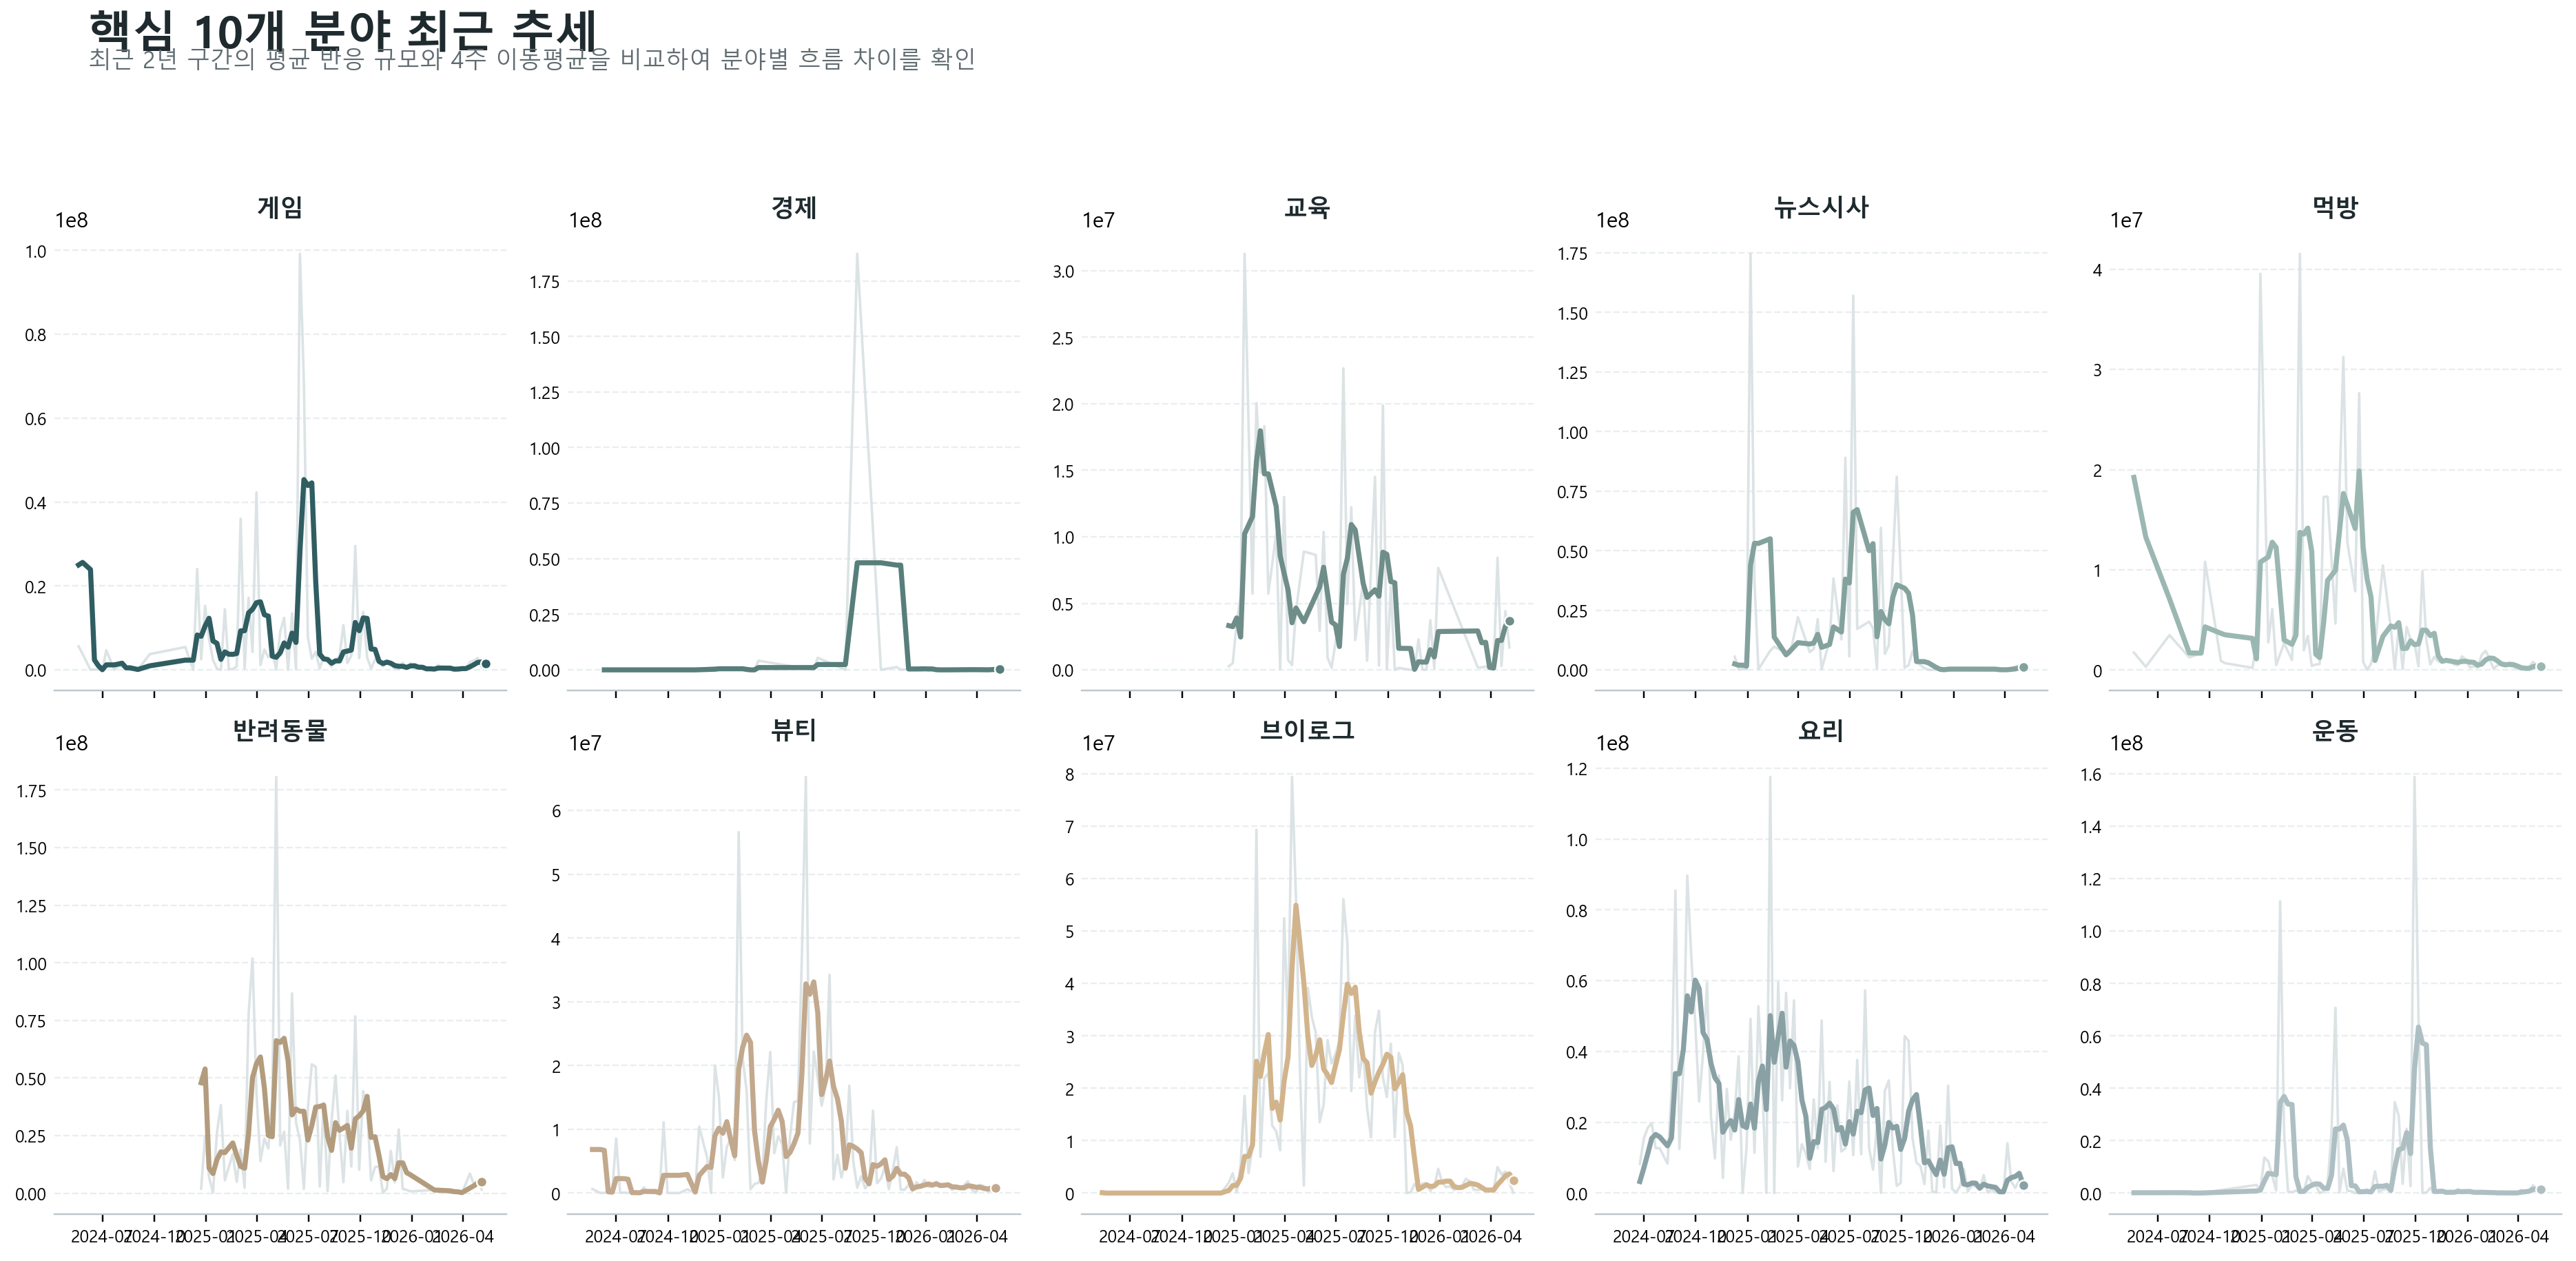

In [8]:
# EDA Figure 1: 핵심 10개 분야 최근 추세
plot_df = feature_df.loc[feature_df["week_date"] >= feature_df["week_date"].max() - pd.Timedelta(weeks=104)].copy()

fig, axes = plt.subplots(2, 5, figsize=(18, 8.8), dpi=220, sharex=True)
axes = axes.flatten()

palette = {
    cat: col for cat, col in zip(
        core10,
        ["#2F5D62", "#577E7A", "#6F8D89", "#84A29D", "#9BB7B1", "#B39C7D", "#C2A88D", "#D2B48C", "#89A1A5", "#AEBFC3"]
    )
}

for ax, category in zip(axes, core10):
    sub = plot_df.loc[plot_df["category"] == category].sort_values("week_date").copy()
    ax.plot(sub["week_date"], sub["avg_virality"], color="#D9E0E3", linewidth=1.2, alpha=0.9)
    ax.plot(sub["week_date"], sub["rolling_4week_mean"], color=palette[category], linewidth=2.4)
    if len(sub):
        ax.scatter(
            sub["week_date"].iloc[-1],
            sub["rolling_4week_mean"].iloc[-1],
            s=24,
            color=palette[category],
            edgecolor="white",
            linewidth=0.8,
            zorder=3,
        )
    ax.set_title(category, fontsize=11.5, color=TEXT, pad=8, fontweight="bold")
    clean_axis(ax, grid_axis="y")
    ax.tick_params(axis="x", labelsize=8)
    ax.tick_params(axis="y", labelsize=8)

fig.suptitle("핵심 10개 분야 최근 추세", x=0.065, y=0.98, ha="left", fontsize=21, fontweight="bold", color=TEXT)
fig.text(0.065, 0.94, "최근 2년 구간의 평균 반응 규모와 4주 이동평균을 비교하여 분야별 흐름 차이를 확인", fontsize=11, color=SUBTEXT)
plt.tight_layout(rect=[0.03, 0.04, 0.98, 0.91])
plt.show()

**해석**  
최근 2년 동안 핵심 10개 분야의 평균 반응 흐름은 서로 다른 패턴을 보였다.  
일부 분야는 특정 시점에 급격한 상승 이후 빠르게 둔화되었고, 다른 분야는 비교적 안정적인 흐름을 유지하였다.  
이는 유튜브 분야별 관심도 변화가 동일하지 않으며, 시간에 따라 서로 다른 추세를 가진다는 점을 보여준다.

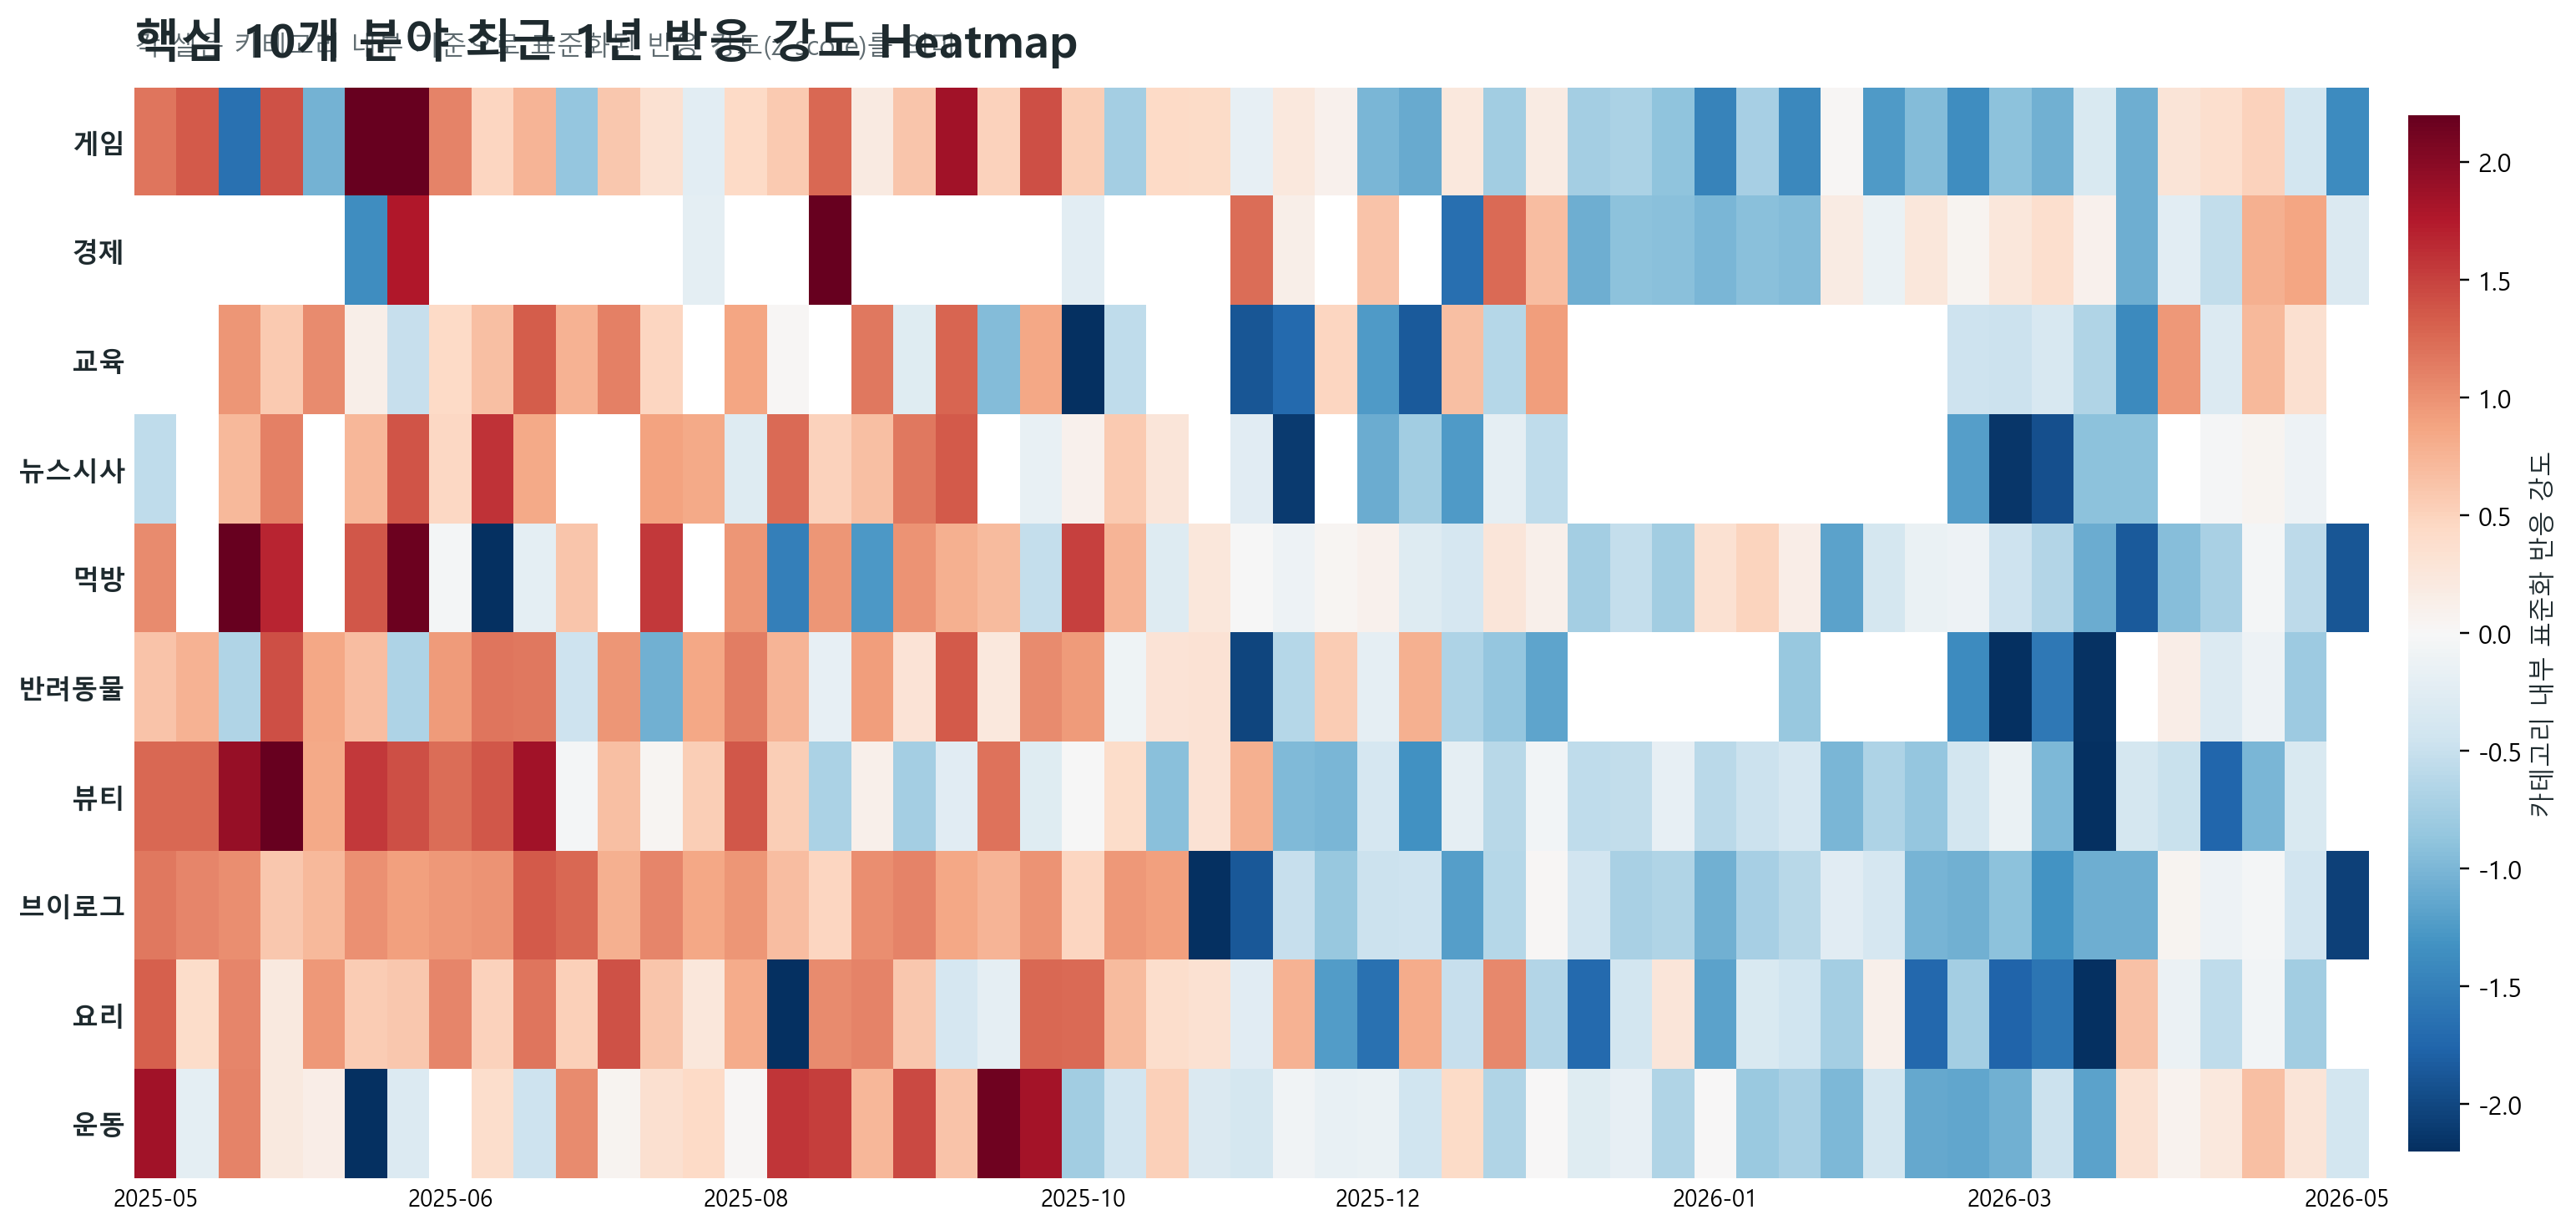

In [9]:
# EDA Figure 2: 반응 강도 heatmap
recent_1y = feature_df.loc[feature_df["week_date"] >= feature_df["week_date"].max() - pd.Timedelta(weeks=52)].copy()
recent_1y["within_cat_z"] = (
    recent_1y.groupby("category")["log_avg_virality"]
    .transform(lambda s: (s - s.mean()) / (s.std(ddof=0) + 1e-9))
)

heat = (
    recent_1y.pivot_table(
        index="category",
        columns="week_date",
        values="within_cat_z",
        aggfunc="mean",
    )
    .reindex(core10)
)

fig, ax = plt.subplots(figsize=(15.5, 6.8), dpi=220)
im = ax.imshow(
    heat.values,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-2.2,
    vmax=2.2,
    interpolation="nearest",
)

date_cols = pd.to_datetime(heat.columns)
tick_idx = np.linspace(0, len(date_cols) - 1, 8, dtype=int)
ax.set_xticks(tick_idx)
ax.set_xticklabels([date_cols[i].strftime("%Y-%m") for i in tick_idx], fontsize=9)
ax.set_yticks(np.arange(len(core10)))
ax.set_yticklabels(core10, fontsize=10.5, color=TEXT, fontweight="bold")

for side in ["top", "right", "left", "bottom"]:
    ax.spines[side].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", length=0)

ax.set_title("핵심 10개 분야 최근 1년 반응 강도 Heatmap", loc="left", fontsize=18, fontweight="bold", color=TEXT, pad=12)
ax.text(0.0, 1.03, "각 셀은 카테고리 내부 기준으로 표준화된 반응 강도(z-score)를 의미", transform=ax.transAxes, fontsize=10.5, color=SUBTEXT)

cbar = plt.colorbar(im, ax=ax, pad=0.015, shrink=0.95)
cbar.outline.set_visible(False)
cbar.set_label("카테고리 내부 표준화 반응 강도", color=TEXT, fontsize=10)

plt.tight_layout()
plt.show()

**해석**  
핵심 10개 분야는 동일한 시점에 함께 상승하지 않으며, 카테고리별로 반응이 집중되는 구간이 다르게 나타난다.  
즉, 전체 플랫폼 수준의 단일 상승보다 **분야별 비동조화된 변화**가 더 강하게 나타난다고 볼 수 있다.

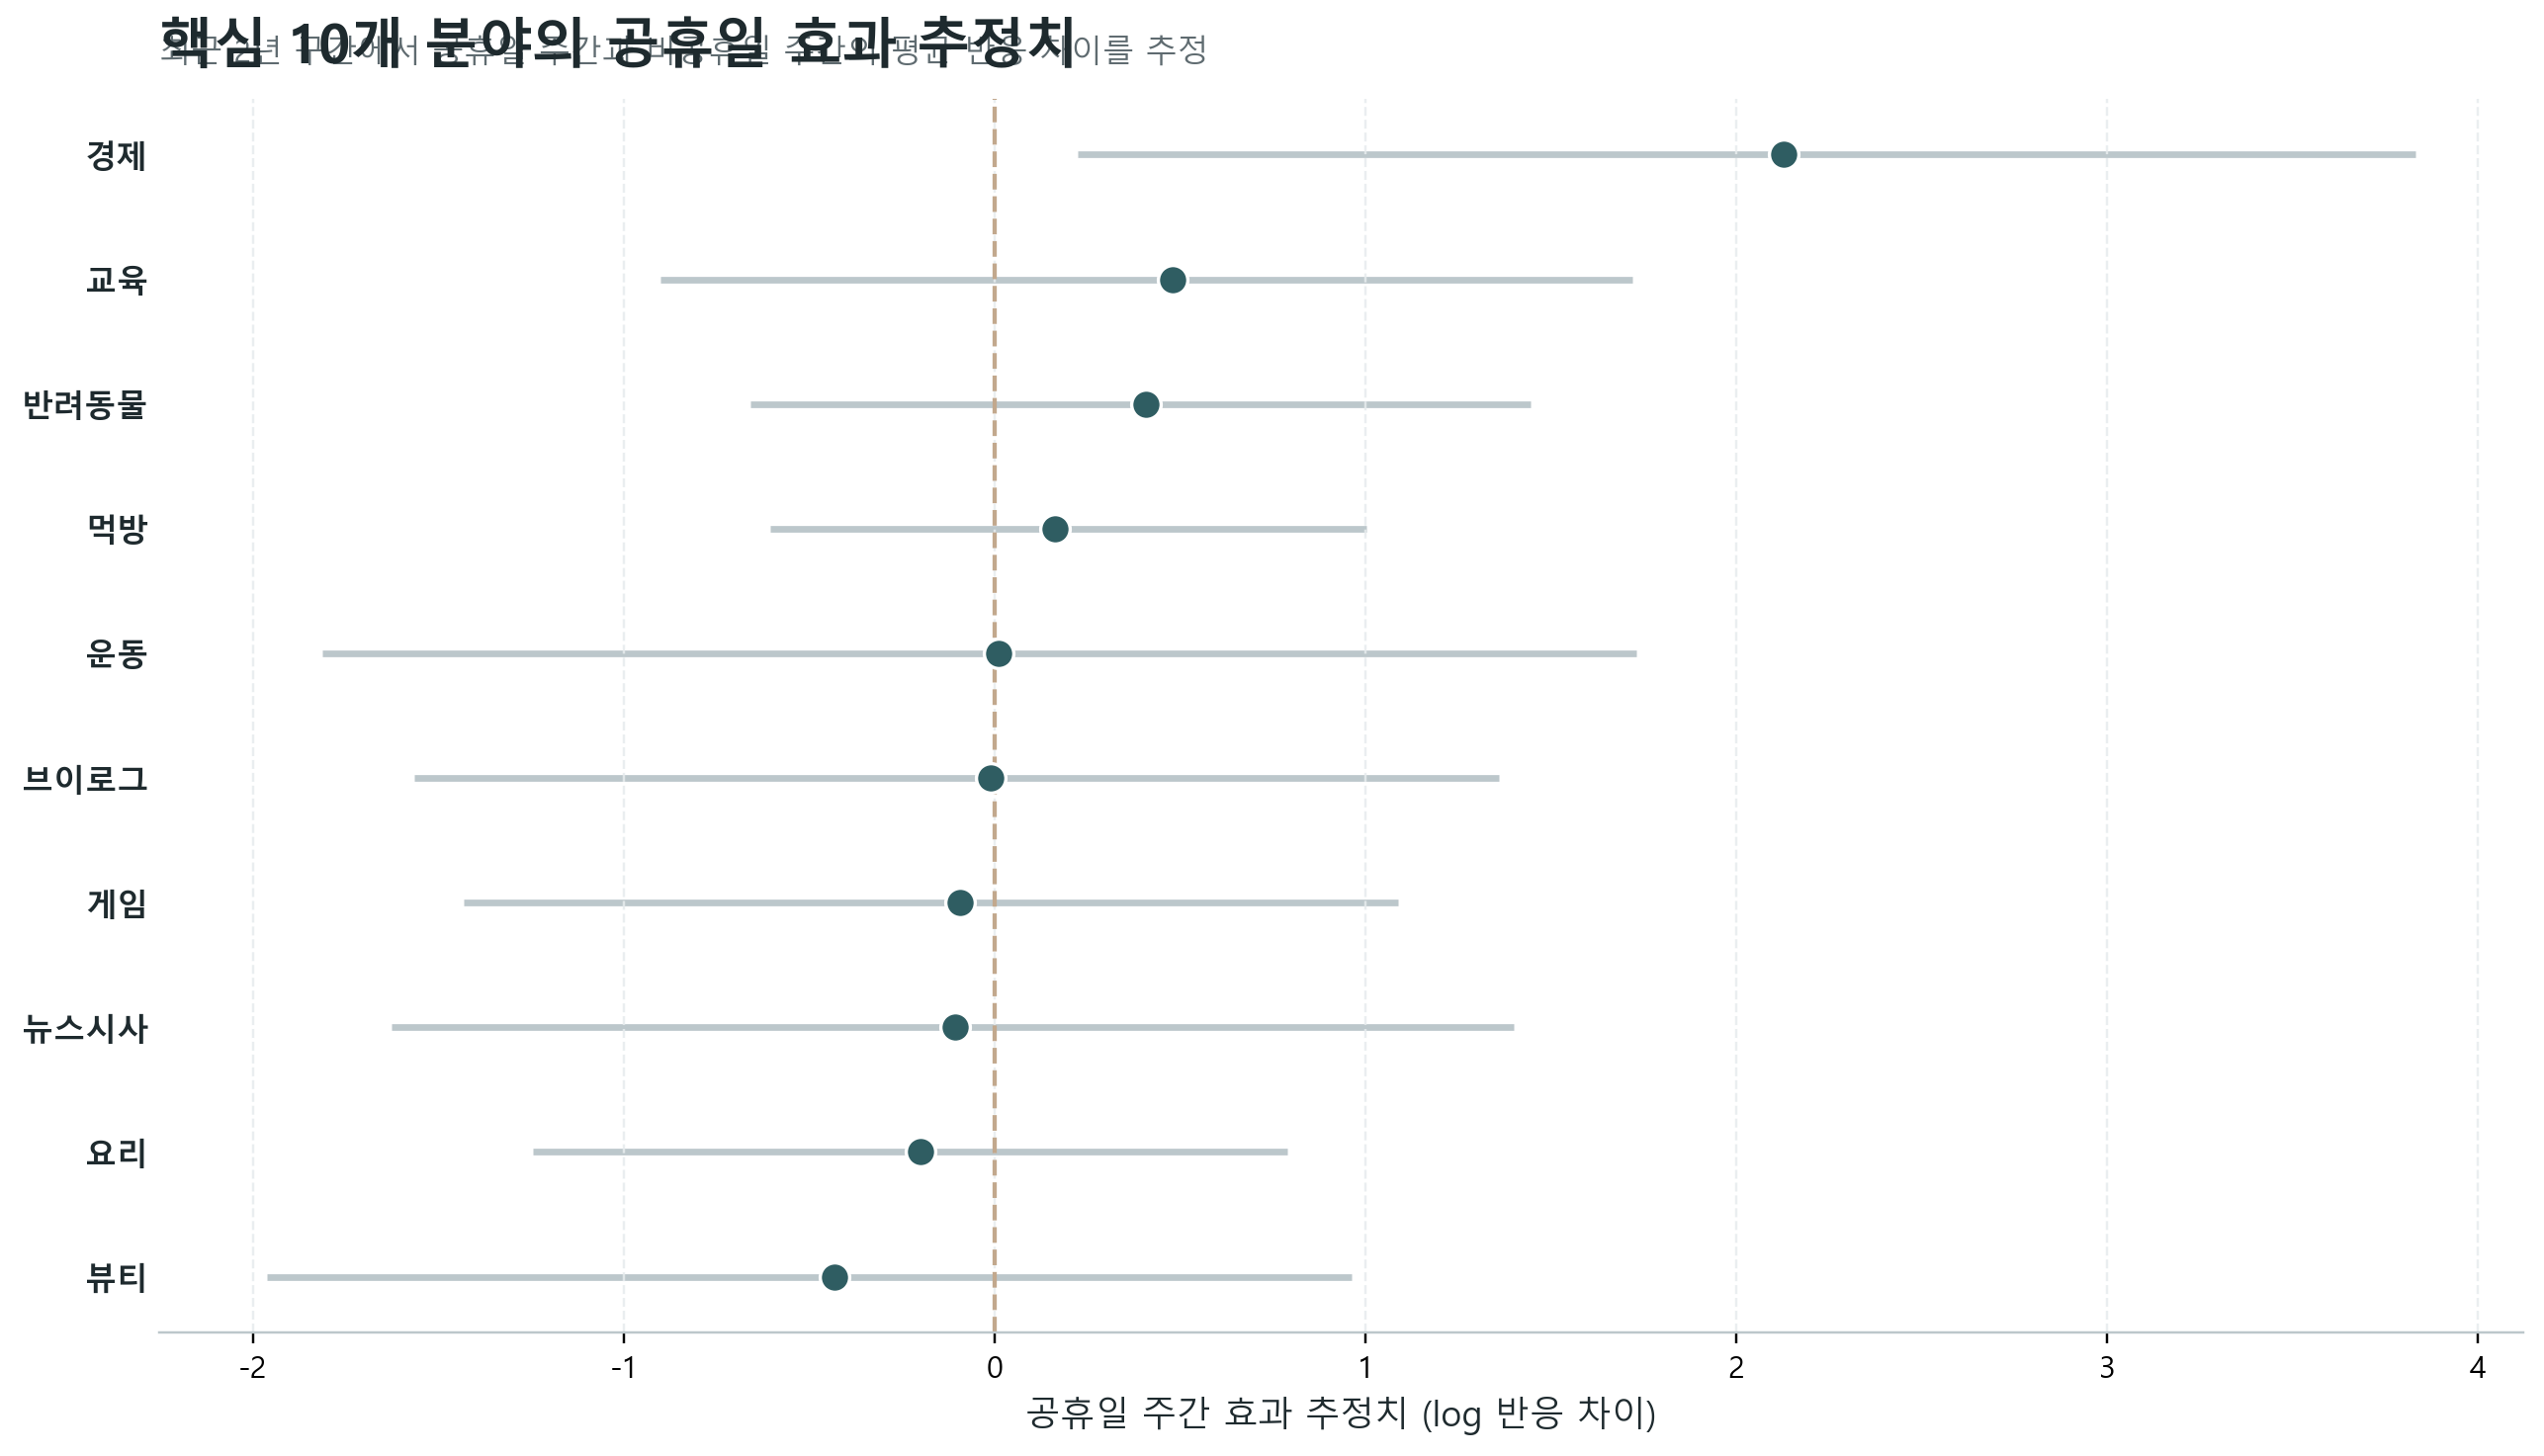

In [10]:
# EDA Figure 3: 공휴일 효과 추정치 coefficient plot
recent_2y = feature_df.loc[feature_df["week_date"] >= feature_df["week_date"].max() - pd.Timedelta(weeks=104)].copy()

def bootstrap_mean_diff(holiday_vals, normal_vals, n_boot=1500, seed=42):
    rng = np.random.default_rng(seed)
    holiday_vals = np.asarray(holiday_vals, dtype=float)
    normal_vals = np.asarray(normal_vals, dtype=float)
    boot = []
    for _ in range(n_boot):
        h = rng.choice(holiday_vals, size=len(holiday_vals), replace=True)
        n = rng.choice(normal_vals, size=len(normal_vals), replace=True)
        boot.append(h.mean() - n.mean())
    boot = np.asarray(boot)
    return float(np.mean(boot)), float(np.quantile(boot, 0.025)), float(np.quantile(boot, 0.975))

rows = []
recent_2y["log_avg_virality"] = np.log1p(recent_2y["avg_virality"])
for category, sub in recent_2y.groupby("category"):
    holiday_vals = sub.loc[sub["is_holiday_week"] > 0, "log_avg_virality"].dropna()
    normal_vals = sub.loc[sub["is_holiday_week"] == 0, "log_avg_virality"].dropna()
    if len(holiday_vals) >= 3 and len(normal_vals) >= 6:
        mean_diff, low, high = bootstrap_mean_diff(holiday_vals, normal_vals)
        rows.append([category, mean_diff, low, high, len(holiday_vals)])

coef_df = pd.DataFrame(rows, columns=["category", "effect", "ci_low", "ci_high", "n_holiday"]).sort_values("effect")
y = np.arange(len(coef_df))

fig, ax = plt.subplots(figsize=(11.8, 6.8), dpi=220)
ax.hlines(y, coef_df["ci_low"], coef_df["ci_high"], color=AXIS, linewidth=2.2, zorder=1)
ax.scatter(coef_df["effect"], y, s=95, color=TEAL, edgecolor="white", linewidth=1.1, zorder=3)
ax.axvline(0, color=SAND, linestyle="--", linewidth=1.4)

ax.set_yticks(y)
ax.set_yticklabels(coef_df["category"], fontsize=10.5, color=TEXT, fontweight="bold")
ax.set_xlabel("공휴일 주간 효과 추정치 (log 반응 차이)", fontsize=11.5, color=TEXT)
clean_axis(ax, grid_axis="x")
ax.set_title("핵심 10개 분야의 공휴일 효과 추정치", loc="left", fontsize=18, fontweight="bold", color=TEXT, pad=12)
ax.text(0.0, 1.03, "최근 2년 구간에서 공휴일 주간과 비공휴일 주간의 평균 반응 차이를 추정", transform=ax.transAxes, fontsize=10.5, color=SUBTEXT)

plt.tight_layout()
plt.show()

**해석**  
분야별로 공휴일 효과의 방향과 크기가 다르게 나타났으며, 일부 분야는 공휴일 주간에 반응이 더 크게 증가하는 경향을 보였다.  
이는 유튜브 분야의 반응이 내부 시계열 정보뿐 아니라 외부 일정 요인의 영향도 받는다는 점을 시사한다.

### ?? EDA ?? 1. ?? ??? ?? ??? ???

? ??? ? ??? **?? ??(?? ??)** ? **?? ?? ??(???)** ? ?? ??? ? ????.  
?? ??? ?? ???? ??? ??? ???? ???? ? ?? ?? ???? ?? ? ????.


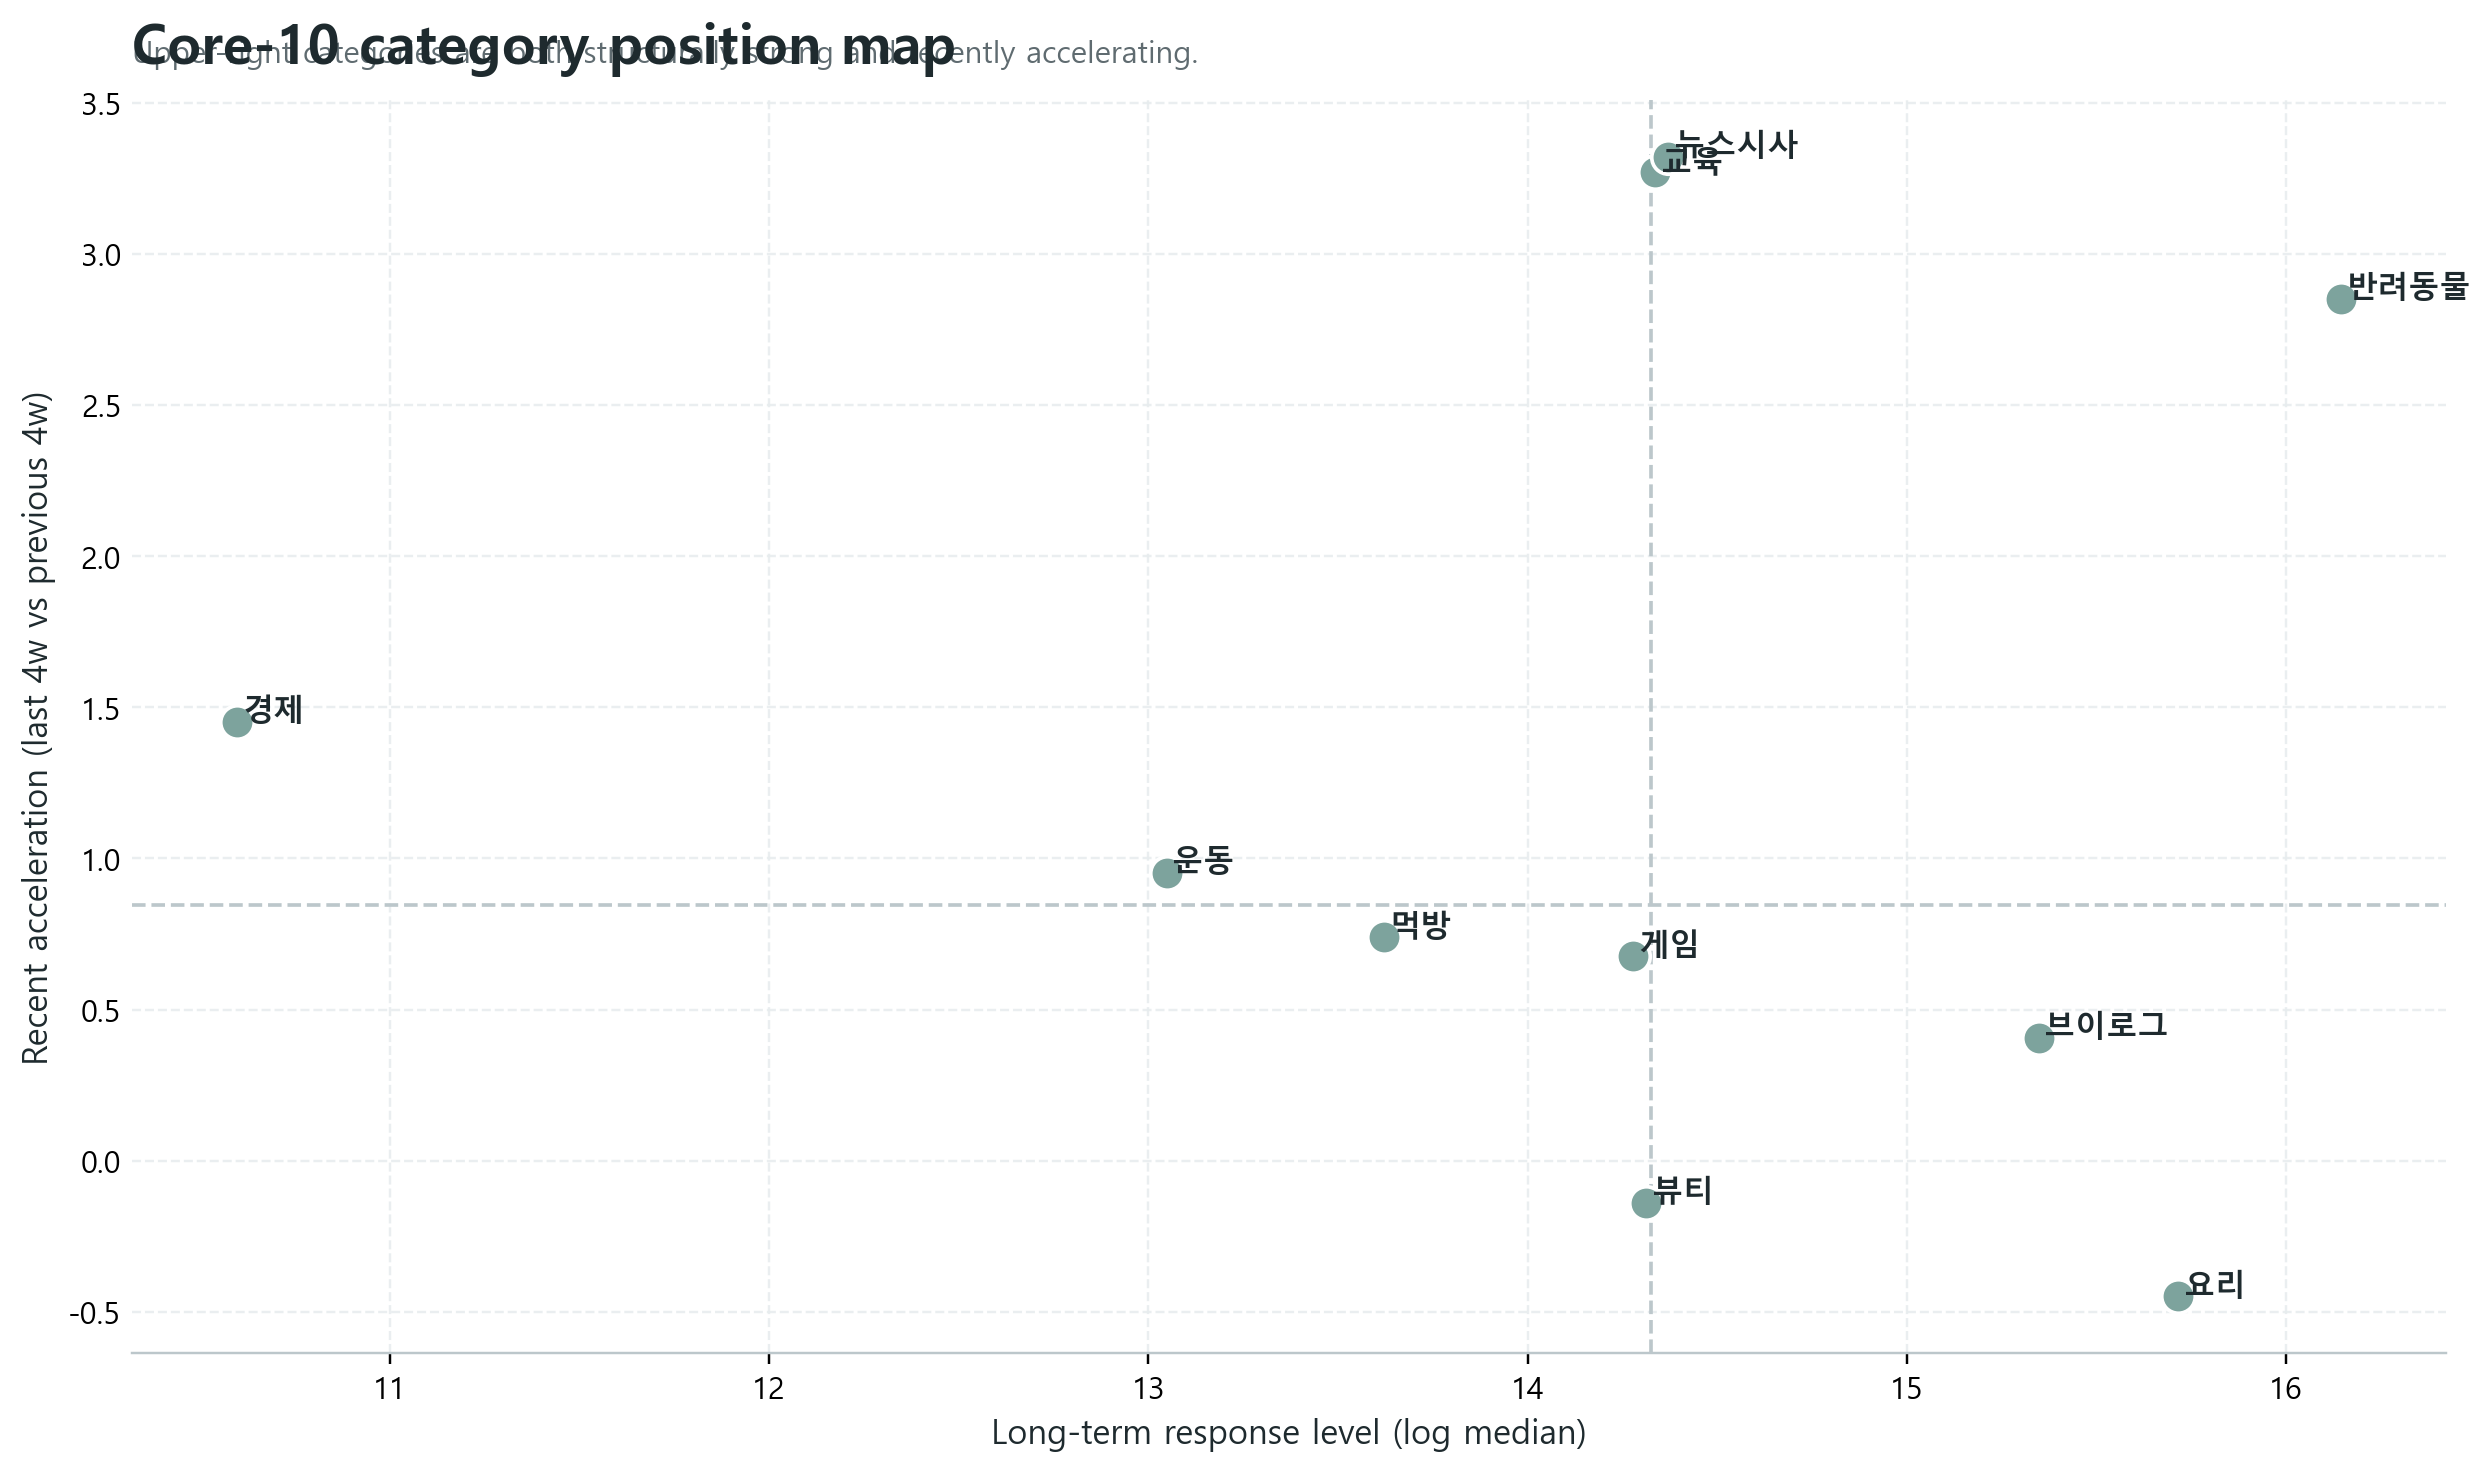

In [11]:
# EDA Figure 4: long-term level vs recent acceleration
position_df = feature_df.loc[
    feature_df["week_date"] >= feature_df["week_date"].max() - pd.Timedelta(weeks=52)
].copy()

rows = []
for category, sub in position_df.groupby("category"):
    sub = sub.sort_values("week_date").copy()
    baseline = float(np.log1p(sub["avg_virality"].median()))
    last4 = float(sub.tail(4)["avg_virality"].mean())
    prev4 = float(sub.tail(8).head(4)["avg_virality"].mean()) if len(sub) >= 8 else float(sub.head(4)["avg_virality"].mean())
    accel = float(np.log1p(last4) - np.log1p(prev4))
    rows.append([category, baseline, accel])

pos_df = pd.DataFrame(rows, columns=["category", "baseline", "accel"])

fig, ax = plt.subplots(figsize=(11.5, 6.8), dpi=220)
ax.scatter(pos_df["baseline"], pos_df["accel"], s=120, color=TEAL_LIGHT, edgecolor="white", linewidth=1.2, zorder=3)
ax.axvline(pos_df["baseline"].median(), color=AXIS, linestyle="--", linewidth=1.2)
ax.axhline(pos_df["accel"].median(), color=AXIS, linestyle="--", linewidth=1.2)

for row in pos_df.itertuples(index=False):
    ax.text(row.baseline + 0.015, row.accel + 0.005, row.category, fontsize=10.2, color=TEXT, fontweight="bold")

clean_axis(ax, grid_axis="both")
ax.set_xlabel("Long-term response level (log median)", fontsize=11.0, color=TEXT)
ax.set_ylabel("Recent acceleration (last 4w vs previous 4w)", fontsize=11.0, color=TEXT)
ax.set_title("Core-10 category position map", loc="left", fontsize=18, fontweight="bold", color=TEXT, pad=12)
ax.text(0.0, 1.03, "Upper-right categories are both structurally strong and recently accelerating.", transform=ax.transAxes, fontsize=10.0, color=SUBTEXT)

plt.tight_layout()
plt.savefig(FIG_DIR / "eda_position_map.png", dpi=300, bbox_inches="tight")
plt.show()


**해석**  

우상단에 위치한 분야는 장기 수준이 높고 최근에도 상승 흐름이 이어지는 분야로 해석할 수 있다.  
반대로 좌상단의 분야는 절대 규모는 상대적으로 작지만 최근 반등 속도가 빠른 신흥 상승 분야로 볼 수 있다.

### ?? EDA ?? 2. ??? ?? ??? ??

? ??? ????? ??? ??? ????? ?????, ?? ?? ??? ????? ?? ?????? ??? ? ????.


C:\Users\mobu3\AppData\Local\Temp\ipykernel_9772\3280614484.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


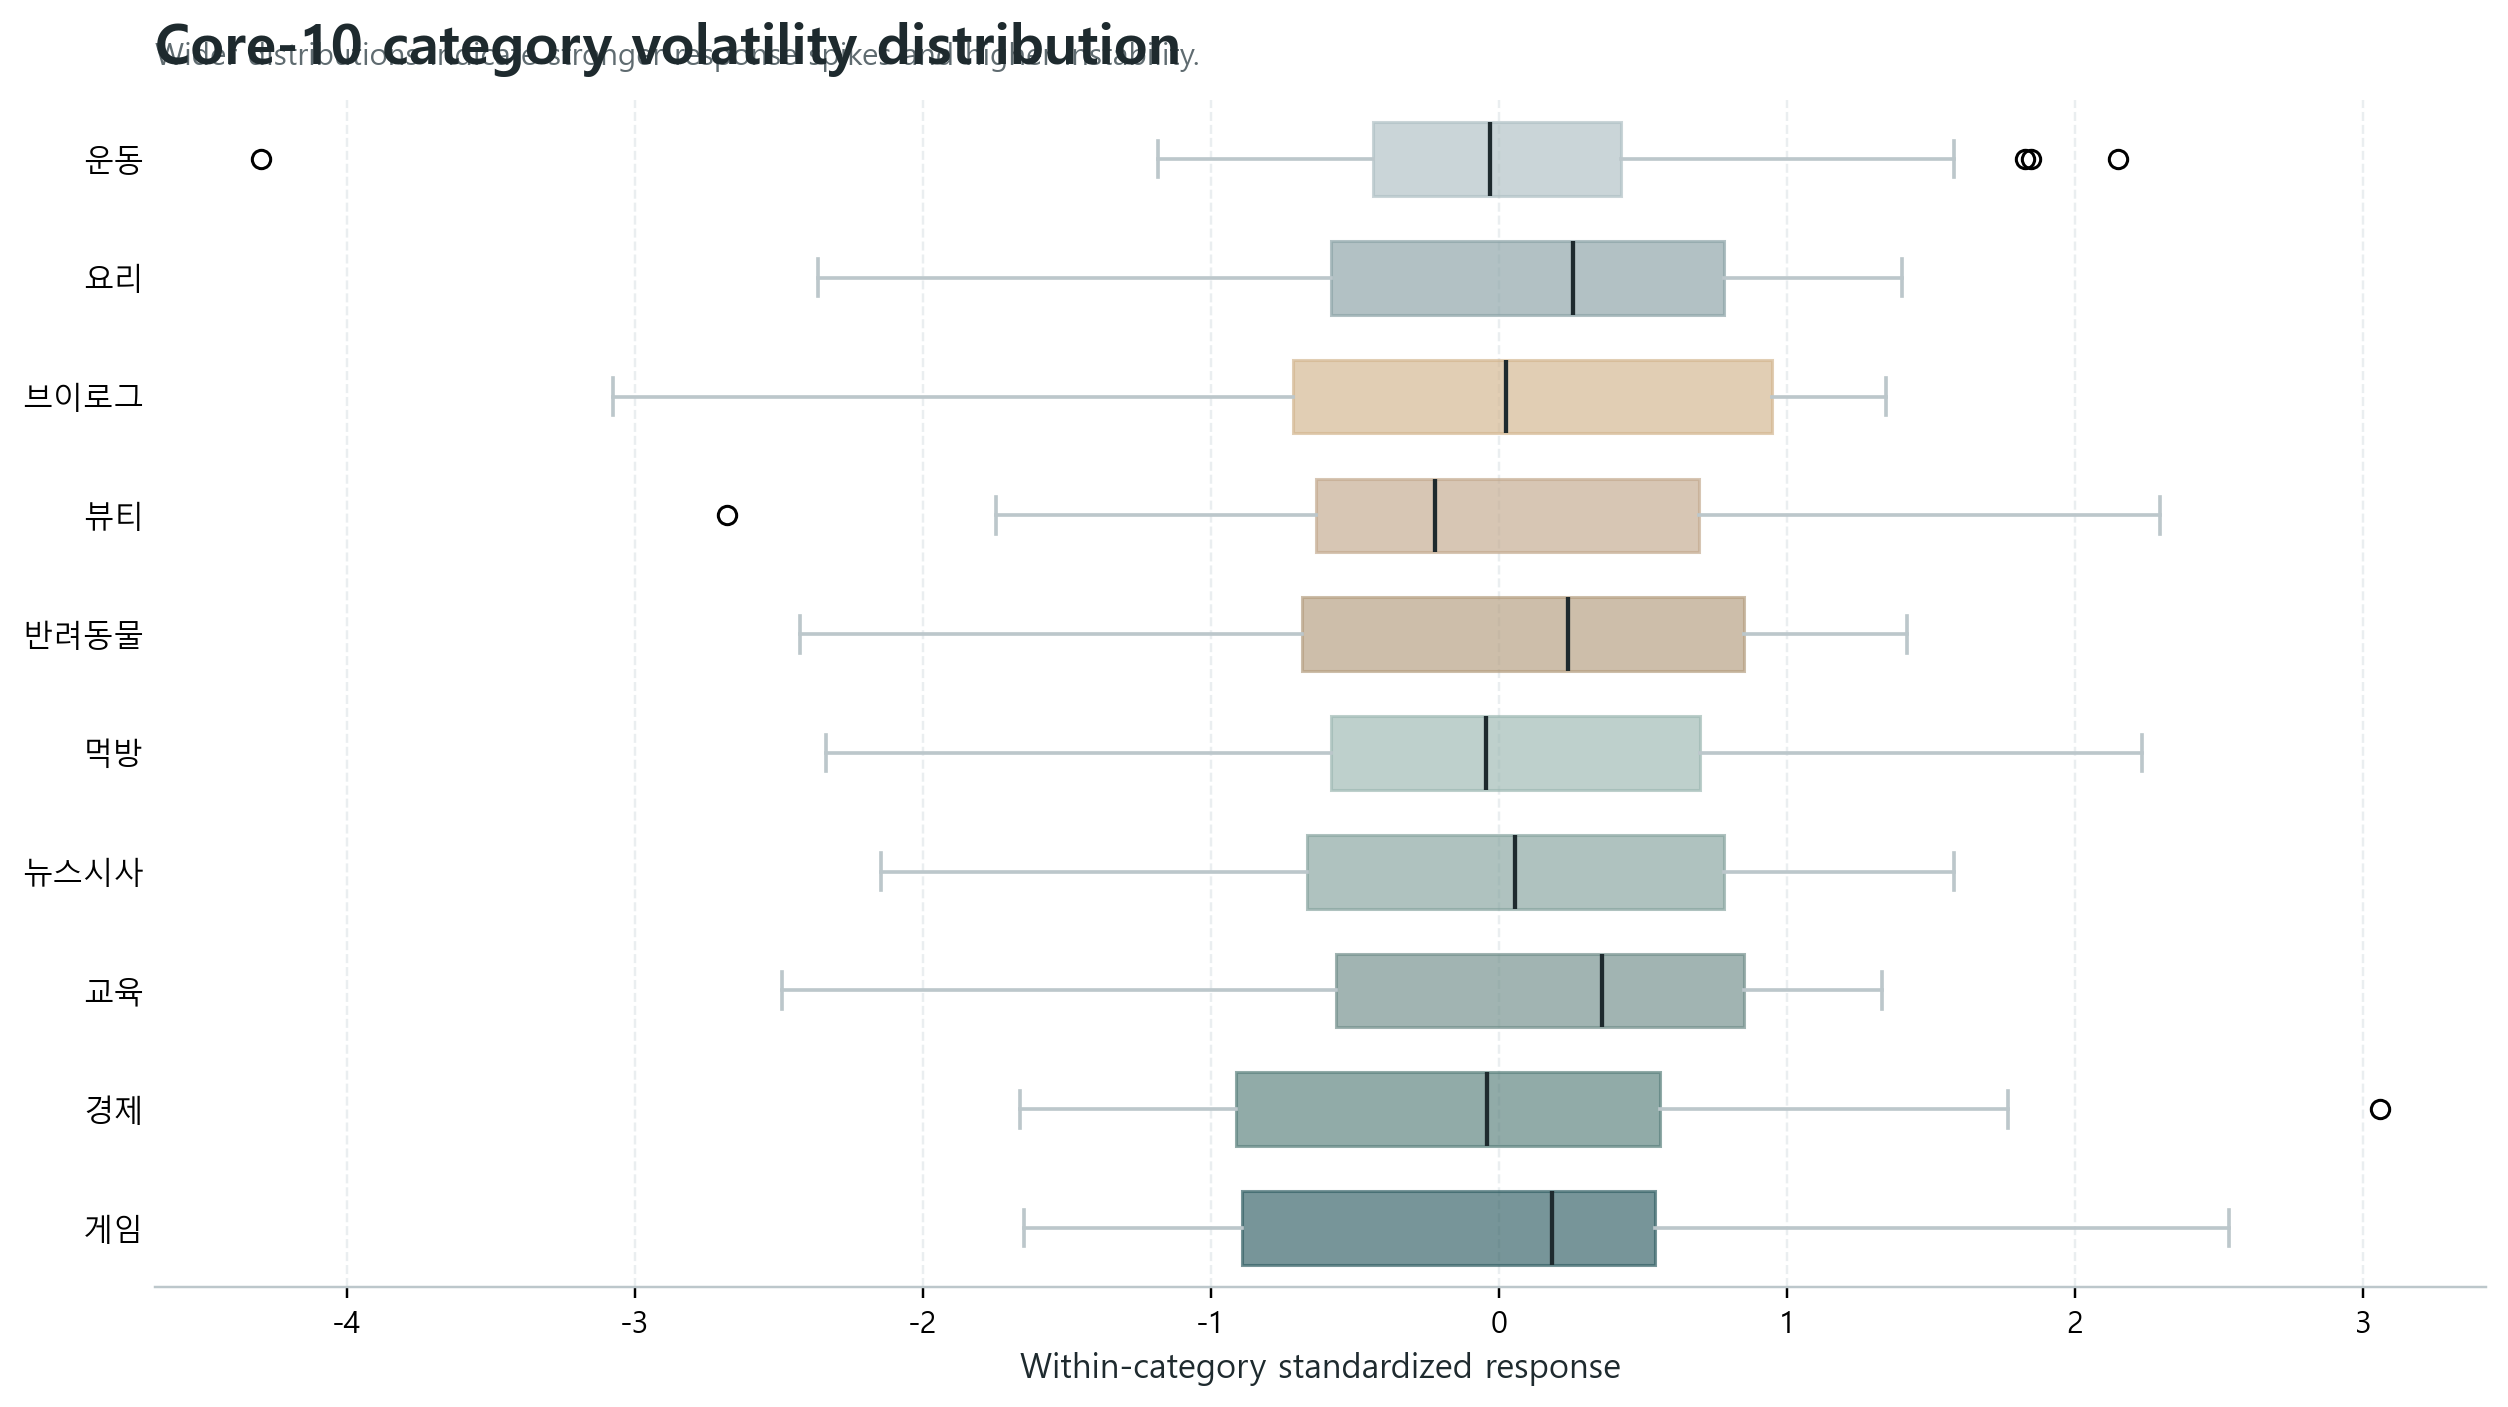

In [12]:
# EDA Figure 5: category-wise volatility distribution
vol_df = feature_df.loc[
    feature_df["week_date"] >= feature_df["week_date"].max() - pd.Timedelta(weeks=52)
].copy()
vol_df["response_z"] = (
    vol_df.groupby("category")["log_avg_virality"]
    .transform(lambda s: (s - s.mean()) / (s.std(ddof=0) + 1e-9))
)

box_data = [vol_df.loc[vol_df["category"] == cat, "response_z"].dropna().values for cat in core10]

fig, ax = plt.subplots(figsize=(11.5, 6.5), dpi=220)
box = ax.boxplot(
    box_data,
    vert=False,
    patch_artist=True,
    labels=core10,
    widths=0.62,
    medianprops=dict(color=TEXT, linewidth=1.4),
    whiskerprops=dict(color=AXIS, linewidth=1.2),
    capprops=dict(color=AXIS, linewidth=1.2),
)

palette = [TEAL, "#577E7A", "#6F8D89", "#84A29D", "#9BB7B1", "#B39C7D", "#C2A88D", "#D2B48C", "#89A1A5", "#AEBFC3"]
for patch, color in zip(box["boxes"], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)
    patch.set_edgecolor(color)
    patch.set_linewidth(1.0)

clean_axis(ax, grid_axis="x")
ax.set_xlabel("Within-category standardized response", fontsize=11.0, color=TEXT)
ax.set_title("Core-10 category volatility distribution", loc="left", fontsize=18, fontweight="bold", color=TEXT, pad=12)
ax.text(0.0, 1.03, "Wider distributions indicate stronger response spikes and higher instability.", transform=ax.transAxes, fontsize=10.0, color=SUBTEXT)

plt.tight_layout()
plt.savefig(FIG_DIR / "eda_volatility_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()


**해석**  

분포 폭이 넓은 분야는 특정 이슈나 이벤트에 따라 반응이 크게 흔들리는 **스파이크 중심 분야**로 해석할 수 있다.  
반대로 분포 폭이 좁은 분야는 상대적으로 안정적인 반응 구조를 가진 분야로 볼 수 있다.

### EDA ??? ?? ???

- **?? ?? EDA?**: `Figure 1`(?? ??), `Figure 2`(?? ?? heatmap)
- **?? ?? ????**: `Figure 3`(??? ?? ???)
- **?? ?? ???**: `Figure 4`(?? ??? ?? ??? ???)
- **???/??? ???**: `Figure 5`(??? ??)

?, ? ???? ?? ??? ??? ?? ?? ??? ??? ?? ??? ????.


## 5. ?? ??: ?? ??? ??? ?? BiGRU


? ??? ?? ??? **RNN ??? ?? ??? ??? ??? BiGRU(Bidirectional Gated Recurrent Unit)** ? ???? ??.

### ?? ?? ??
- `RNN`? ?? ???? ?? ???? ???? ?? ????.
- `GRU`? RNN? ?? ??? ??? ??? ??? ?? ????.
- `BiGRU`? GRU? ????? ???? ?? 12? ???? ?? ??? ?? ??? ? ??.

### ? BiGRU? ??????
- ?? 12? ???? ?? ????? **?? ??? ?? ?? ??**? ?? ??? ? ??.
- ?? MLP?? **?? ?? ??**? ?? ??? ? ??, ?? ??? ????? Transformer?? ? ????? ????.
- category embedding? ??? **??? ?? ??**? **?? ??? ??**? ?? ??? ? ??.

### ? ??? ??????? ?? ??? ????
- ???? ?? ?? ?? ??, ?? 12? ???? ?? ??? ???? **?? ?? ??**? ????.
- ? ?? ??? **?? ??**? **?? ?? ??**? ????.
- ????? ? ??? ??? **?? 4? Top-N ?? ??**? ????.


In [13]:
from train_active_category_rank_bigru import (
    CategoryConditionedBiGRU,
    SEQUENCE_FEATURE_COLS,
    FUTURE_CAL_COLS,
)

model = CategoryConditionedBiGRU(
    input_dim=len(SEQUENCE_FEATURE_COLS),
    future_cal_dim=len(FUTURE_CAL_COLS),
    category_count=len(core10),
)
model

CategoryConditionedBiGRU(
  (category_embed): Embedding(10, 10)
  (seq_proj): Sequential(
    (0): Linear(in_features=44, out_features=96, bias=True)
    (1): GELU(approximate='none')
    (2): LayerNorm((96,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (gru): GRU(96, 96, num_layers=2, batch_first=True, dropout=0.18, bidirectional=True)
  (future_proj): Sequential(
    (0): Linear(in_features=9, out_features=48, bias=True)
    (1): GELU(approximate='none')
    (2): LayerNorm((48,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (shared): Sequential(
    (0): Linear(in_features=442, out_features=192, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.18, inplace=False)
    (3): LayerNorm((192,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (rise_head): Linear(in_features=192, out_features=1, bias=True)
  (rank_head): Linear(in_features=192, out_features=1, bias=True)
  (step_head): Linear(in_features=192, out_features=4, bias=True)
  (score_head): L

## 6. 모델 설계 및 입력/출력 구조

### 예측 대상
- 예측 단위: 유튜브 핵심 10개 분야
- 예측 기간: 다음 4주
- 대상 분야: 게임, 경제, 교육, 뉴스시사, 먹방, 반려동물, 뷰티, 브이로그, 요리, 운동

### 입력
1. 내부 시계열 입력: 최근 12주 카테고리 반응 추세  
2. 외부 변수 입력: Google Trends 검색량, 공휴일, 연휴, 방학, 시험기간  
3. 카테고리 정보: category embedding

### 출력
- 상승 확률
- 순위 상승 확률
- 보조 랭킹 점수
- 최종적으로 상승 확률과 순위 상승 확률을 조합하여 Top-N 상승 분야를 선별

In [14]:
core10_summary = json.loads(SUMMARY_PATH.read_text(encoding="utf-8"))
config_df = pd.DataFrame(
    {
        "항목": [
            "model_name",
            "feature_mode",
            "quantile",
            "threshold",
            "train_windows",
            "val_windows",
            "test_windows",
            "blend_ranking_score",
            "blend_rise_probability",
            "blend_rank_up_probability",
        ],
        "값": [
            core10_summary["model_name"],
            core10_summary["feature_mode"],
            core10_summary["quantile"],
            core10_summary["threshold"],
            core10_summary["train_windows"],
            core10_summary["val_windows"],
            core10_summary["test_windows"],
            core10_summary["blend_weights"]["ranking_score"],
            core10_summary["blend_weights"]["rise_probability"],
            core10_summary["blend_weights"]["rank_up_probability"],
        ],
    }
)
config_df

,항목,값
0,model_name,CategoryConditionedBiGRU_RankingAwareRiseModel...
1,feature_mode,calendar_search
2,quantile,0.6
3,threshold,0.4
4,train_windows,567
5,val_windows,29
6,test_windows,30
7,blend_ranking_score,0.0
8,blend_rise_probability,0.4
9,blend_rank_up_probability,0.6


In [15]:
# 선택 실행: 최종 예측 결과를 다시 생성하고 싶을 때 사용
# from run_core10_top_predictions import main as rerun_core10_predictions
# rerun_core10_predictions()

## 7. 모델 성능 평가

최종 코어 10개 BiGRU 모델은 **분류 성능**과 **Top-5 선별 성능**을 함께 평가하였다.

- 분류 성능 지표: Accuracy, Balanced Accuracy, F1-score, ROC AUC
- Top-N 선별 지표: Precision@5, Recall@5, HitRate@5, NDCG@5

In [16]:
val_metrics = core10_summary["val_metrics"]
test_metrics = core10_summary["test_metrics"]
rank_metrics = core10_summary["test_ranking_metrics"]

metrics_table = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Balanced Accuracy", "Precision", "Recall", "F1-score", "ROC AUC"],
        "Validation": [
            val_metrics["accuracy"],
            val_metrics["balanced_accuracy"],
            val_metrics["precision"],
            val_metrics["recall"],
            val_metrics["f1"],
            val_metrics["roc_auc"],
        ],
        "Test": [
            test_metrics["accuracy"],
            test_metrics["balanced_accuracy"],
            test_metrics["precision"],
            test_metrics["recall"],
            test_metrics["f1"],
            test_metrics["roc_auc"],
        ],
    }
)

ranking_table = pd.DataFrame(
    {
        "Metric": ["Precision@5", "Recall@5", "HitRate@5", "NDCG@5"],
        "Test": [
            rank_metrics["precision_at_5"],
            rank_metrics["recall_at_5"],
            rank_metrics["hit_rate_at_5"],
            rank_metrics["ndcg_at_5"],
        ],
    }
)

display(metrics_table)
display(ranking_table)

,Metric,Validation,Test
0,Accuracy,0.758621,0.766667
1,Balanced Accuracy,0.794444,0.798137
2,Precision,0.571429,0.944444
3,Recall,0.888889,0.739130
4,F1-score,0.695652,0.829268
5,ROC AUC,0.838889,0.844720


,Metric,Test
0,Precision@5,0.900000
1,Recall@5,0.801190
2,HitRate@5,1.000000
3,NDCG@5,0.881152


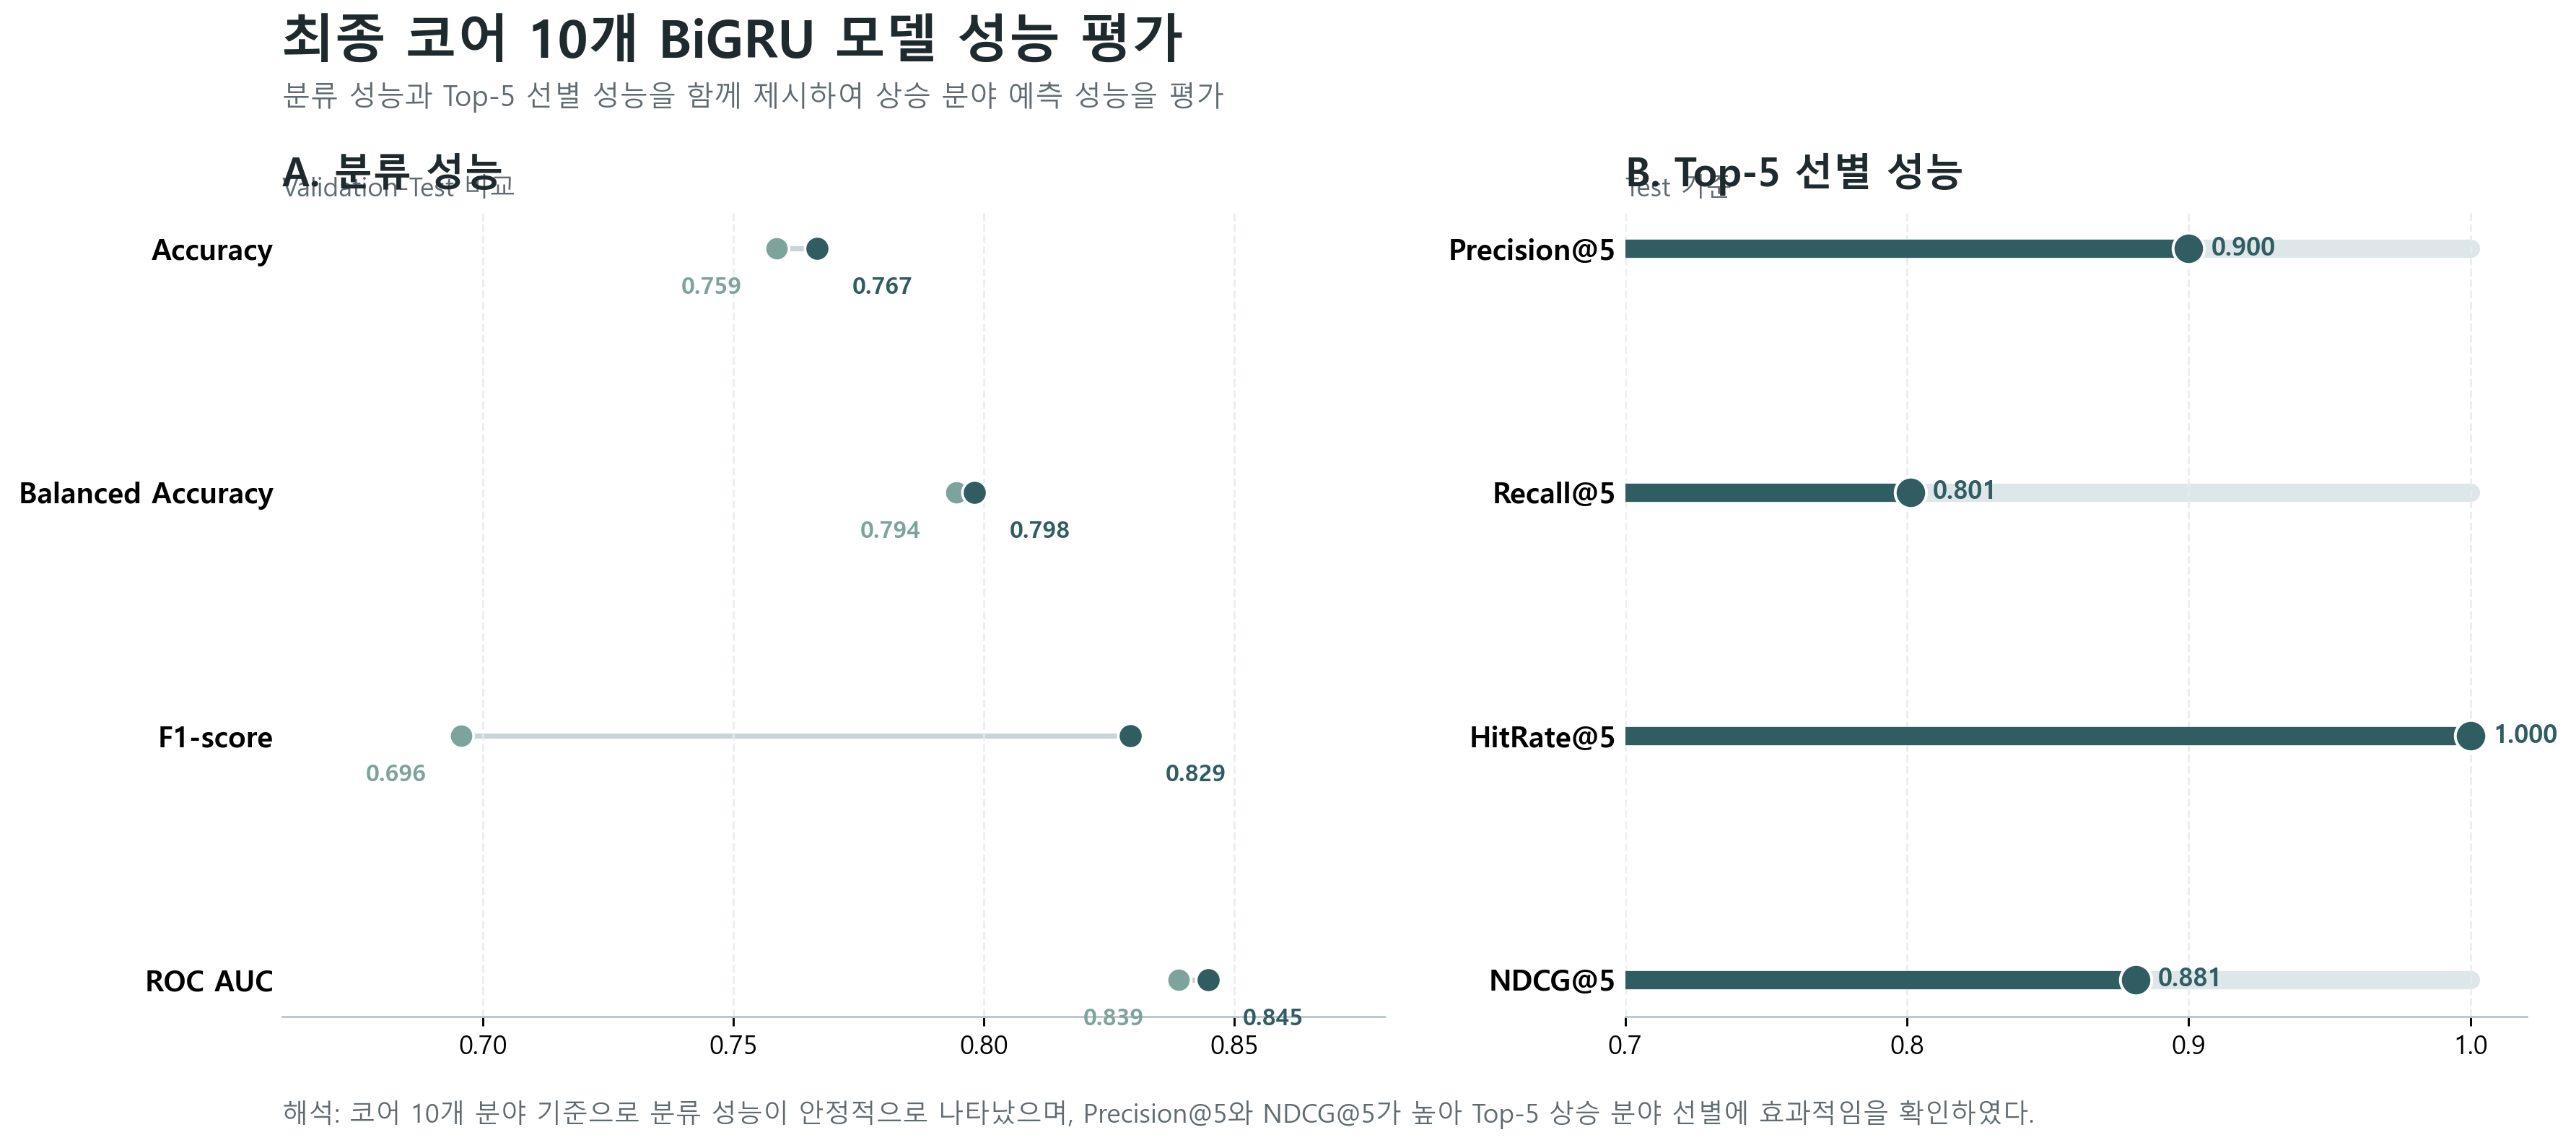

In [17]:
cls_df = pd.DataFrame({
    "Metric": ["Accuracy", "Balanced Accuracy", "F1-score", "ROC AUC"],
    "Validation": [
        val_metrics["accuracy"],
        val_metrics["balanced_accuracy"],
        val_metrics["f1"],
        val_metrics["roc_auc"],
    ],
    "Test": [
        test_metrics["accuracy"],
        test_metrics["balanced_accuracy"],
        test_metrics["f1"],
        test_metrics["roc_auc"],
    ],
})

rank_df = pd.DataFrame({
    "Metric": ["Precision@5", "Recall@5", "HitRate@5", "NDCG@5"],
    "Score": [
        rank_metrics["precision_at_5"],
        rank_metrics["recall_at_5"],
        rank_metrics["hit_rate_at_5"],
        rank_metrics["ndcg_at_5"],
    ],
})

fig = plt.figure(figsize=(13.0, 6.3), dpi=260)
gs = fig.add_gridspec(1, 2, width_ratios=[1.1, 0.9], left=0.06, right=0.98, top=0.82, bottom=0.14, wspace=0.24)

ax1 = fig.add_subplot(gs[0, 0])
y = np.arange(len(cls_df))
for i, row in cls_df.iterrows():
    ax1.plot([row["Validation"], row["Test"]], [i, i], color=LINK, linewidth=2.0, zorder=1)
ax1.scatter(cls_df["Validation"], y, s=85, color=TEAL_LIGHT, edgecolor="white", linewidth=1.0, zorder=3)
ax1.scatter(cls_df["Test"], y, s=90, color=TEAL, edgecolor="white", linewidth=1.0, zorder=3)
for i, row in cls_df.iterrows():
    ax1.text(row["Validation"] - 0.007, i + 0.16, f"{row['Validation']:.3f}", fontsize=9.0, color=TEAL_LIGHT, ha="right", va="center", fontweight="bold")
    ax1.text(row["Test"] + 0.007, i + 0.16, f"{row['Test']:.3f}", fontsize=9.0, color=TEAL, ha="left", va="center", fontweight="bold")
ax1.set_yticks(y)
ax1.set_yticklabels(cls_df["Metric"], fontsize=11, fontweight="bold")
ax1.set_xlim(0.66, 0.88)
ax1.set_xticks([0.70, 0.75, 0.80, 0.85])
ax1.invert_yaxis()
clean_axis(ax1, grid_axis="x")
ax1.set_title("A. 분류 성능", loc="left", fontsize=15, fontweight="bold", color=TEXT, pad=10)
ax1.text(0.0, 1.02, "Validation-Test 비교", transform=ax1.transAxes, fontsize=10.0, color=SUBTEXT)

ax2 = fig.add_subplot(gs[0, 1])
y2 = np.arange(len(rank_df))
for yi, score in zip(y2, rank_df["Score"]):
    ax2.hlines(yi, 0.70, 1.00, color="#DDE6E9", linewidth=7, zorder=1, capstyle="round")
    ax2.hlines(yi, 0.70, score, color=TEAL, linewidth=7, zorder=2, capstyle="round")
    ax2.scatter(score, yi, s=145, color=TEAL, edgecolor="white", linewidth=1.1, zorder=3)
    ax2.text(score + 0.008, yi, f"{score:.3f}", fontsize=9.6, color=TEAL, va="center", ha="left", fontweight="bold")
ax2.set_yticks(y2)
ax2.set_yticklabels(rank_df["Metric"], fontsize=11, fontweight="bold")
ax2.set_xlim(0.70, 1.02)
ax2.set_xticks([0.70, 0.80, 0.90, 1.00])
ax2.invert_yaxis()
clean_axis(ax2, grid_axis="x")
ax2.set_title("B. Top-5 선별 성능", loc="left", fontsize=15, fontweight="bold", color=TEXT, pad=10)
ax2.text(0.0, 1.02, "Test 기준", transform=ax2.transAxes, fontsize=10.0, color=SUBTEXT)

fig.text(0.06, 0.95, "최종 코어 10개 BiGRU 모델 성능 평가", fontsize=20, fontweight="bold", color=TEXT, ha="left")
fig.text(0.06, 0.91, "분류 성능과 Top-5 선별 성능을 함께 제시하여 상승 분야 예측 성능을 평가", fontsize=10.8, color=SUBTEXT, ha="left")
fig.text(0.06, 0.05, "해석: 코어 10개 분야 기준으로 분류 성능이 안정적으로 나타났으며, Precision@5와 NDCG@5가 높아 Top-5 상승 분야 선별에 효과적임을 확인하였다.", fontsize=10.0, color=SUBTEXT, ha="left")
plt.show()

**핵심 결과**

- Accuracy `0.767`
- Balanced Accuracy `0.798`
- F1-score `0.829`
- ROC AUC `0.845`
- Precision@5 `0.900`
- Recall@5 `0.801`
- HitRate@5 `1.000`
- NDCG@5 `0.881`

즉, 최종 코어 10개 BiGRU 모델은 **상승/비상승 분류 성능**과 **Top-5 선별 성능** 모두에서 발표 가능한 수준의 결과를 보였다.

### 냉정한 해석

- 이 성능은 **전체 20개 분야**가 아니라, 최근 활동이 충분한 **핵심 10개 분야**로 범위를 좁혔을 때 얻은 결과이다.
- 따라서 본 모델은 모든 유튜브 분야를 포괄하는 범용 예측기라기보다, **핵심 분야 Top-5 선별 모델**로 해석하는 것이 타당하다.
- 그럼에도 불구하고 temporal split과 미래 정보 차단 조건을 유지한 상태에서 Top-5 선별 성능이 높게 나타났다는 점은 발표에서 충분히 강조할 수 있다.

## 8. ?? ?? ? ??? ???

?? ??? ??? ??? ??? ?? ???, **?? ??**, **?? ??**, **?? ??**, **??? ?? ????**, **4? ?? ?? ??**? ?? ?? ?? ??? ?? ????.

? ??? ?? ??? ??? ??.
- ?? ??? ?? Top-5 ????? ???????
- ?? ??? ?? ??? ?? ?? ?? ? ??? ??? ? ?? ????
- ?? ?? ??? ?? ?? ??? ?? ????? ?? ???? ?????
- ? ?? ??? t+1?? t+4?? ?? ?? ??? ?????


?? ??? ?? ?? ?? ?? ?? ????, ??? ?? ??? ???? ??? ? ?? ?? ?? ??? ??? ????.


In [18]:
top_df

,category,rise_probability,rank_up_probability,ranking_score,final_score
0,반려동물,0.410437,0.527398,0.513827,0.480614
1,먹방,0.407319,0.506435,0.555170,0.466788
2,경제,0.416125,0.489018,0.550891,0.459861
3,브이로그,0.439414,0.470471,0.587549,0.458048
4,교육,0.346361,0.483269,0.495771,0.428506
5,요리,0.360638,0.439827,0.602030,0.408151
6,운동,0.341121,0.408609,0.486846,0.381614
7,게임,0.260742,0.451287,0.441916,0.375069
8,뉴스시사,0.358642,0.339956,0.515121,0.347430
9,뷰티,0.283274,0.372872,0.436896,0.337032


In [19]:
future_df.head(10)

,category,rise_probability,rank_up_probability,ranking_score,step1_up_probability,step2_up_probability,step3_up_probability,step4_up_probability
0,요리,0.360638,0.439827,0.602030,0.397086,0.625806,0.378135,0.359283
1,브이로그,0.439414,0.470471,0.587549,0.467683,0.544588,0.455728,0.522385
2,먹방,0.407319,0.506435,0.555170,0.413821,0.614383,0.368262,0.478145
3,경제,0.416125,0.489018,0.550891,0.477347,0.678210,0.439157,0.483094
4,뉴스시사,0.358642,0.339956,0.515121,0.426067,0.589454,0.470051,0.491302
5,반려동물,0.410437,0.527398,0.513827,0.404443,0.470138,0.537667,0.479783
6,교육,0.346361,0.483269,0.495771,0.407535,0.387962,0.451055,0.401582
7,운동,0.341121,0.408609,0.486846,0.434707,0.488886,0.382078,0.386838
8,게임,0.260742,0.451287,0.441916,0.474242,0.481666,0.431824,0.447868
9,뷰티,0.283274,0.372872,0.436896,0.432338,0.420499,0.506028,0.427704


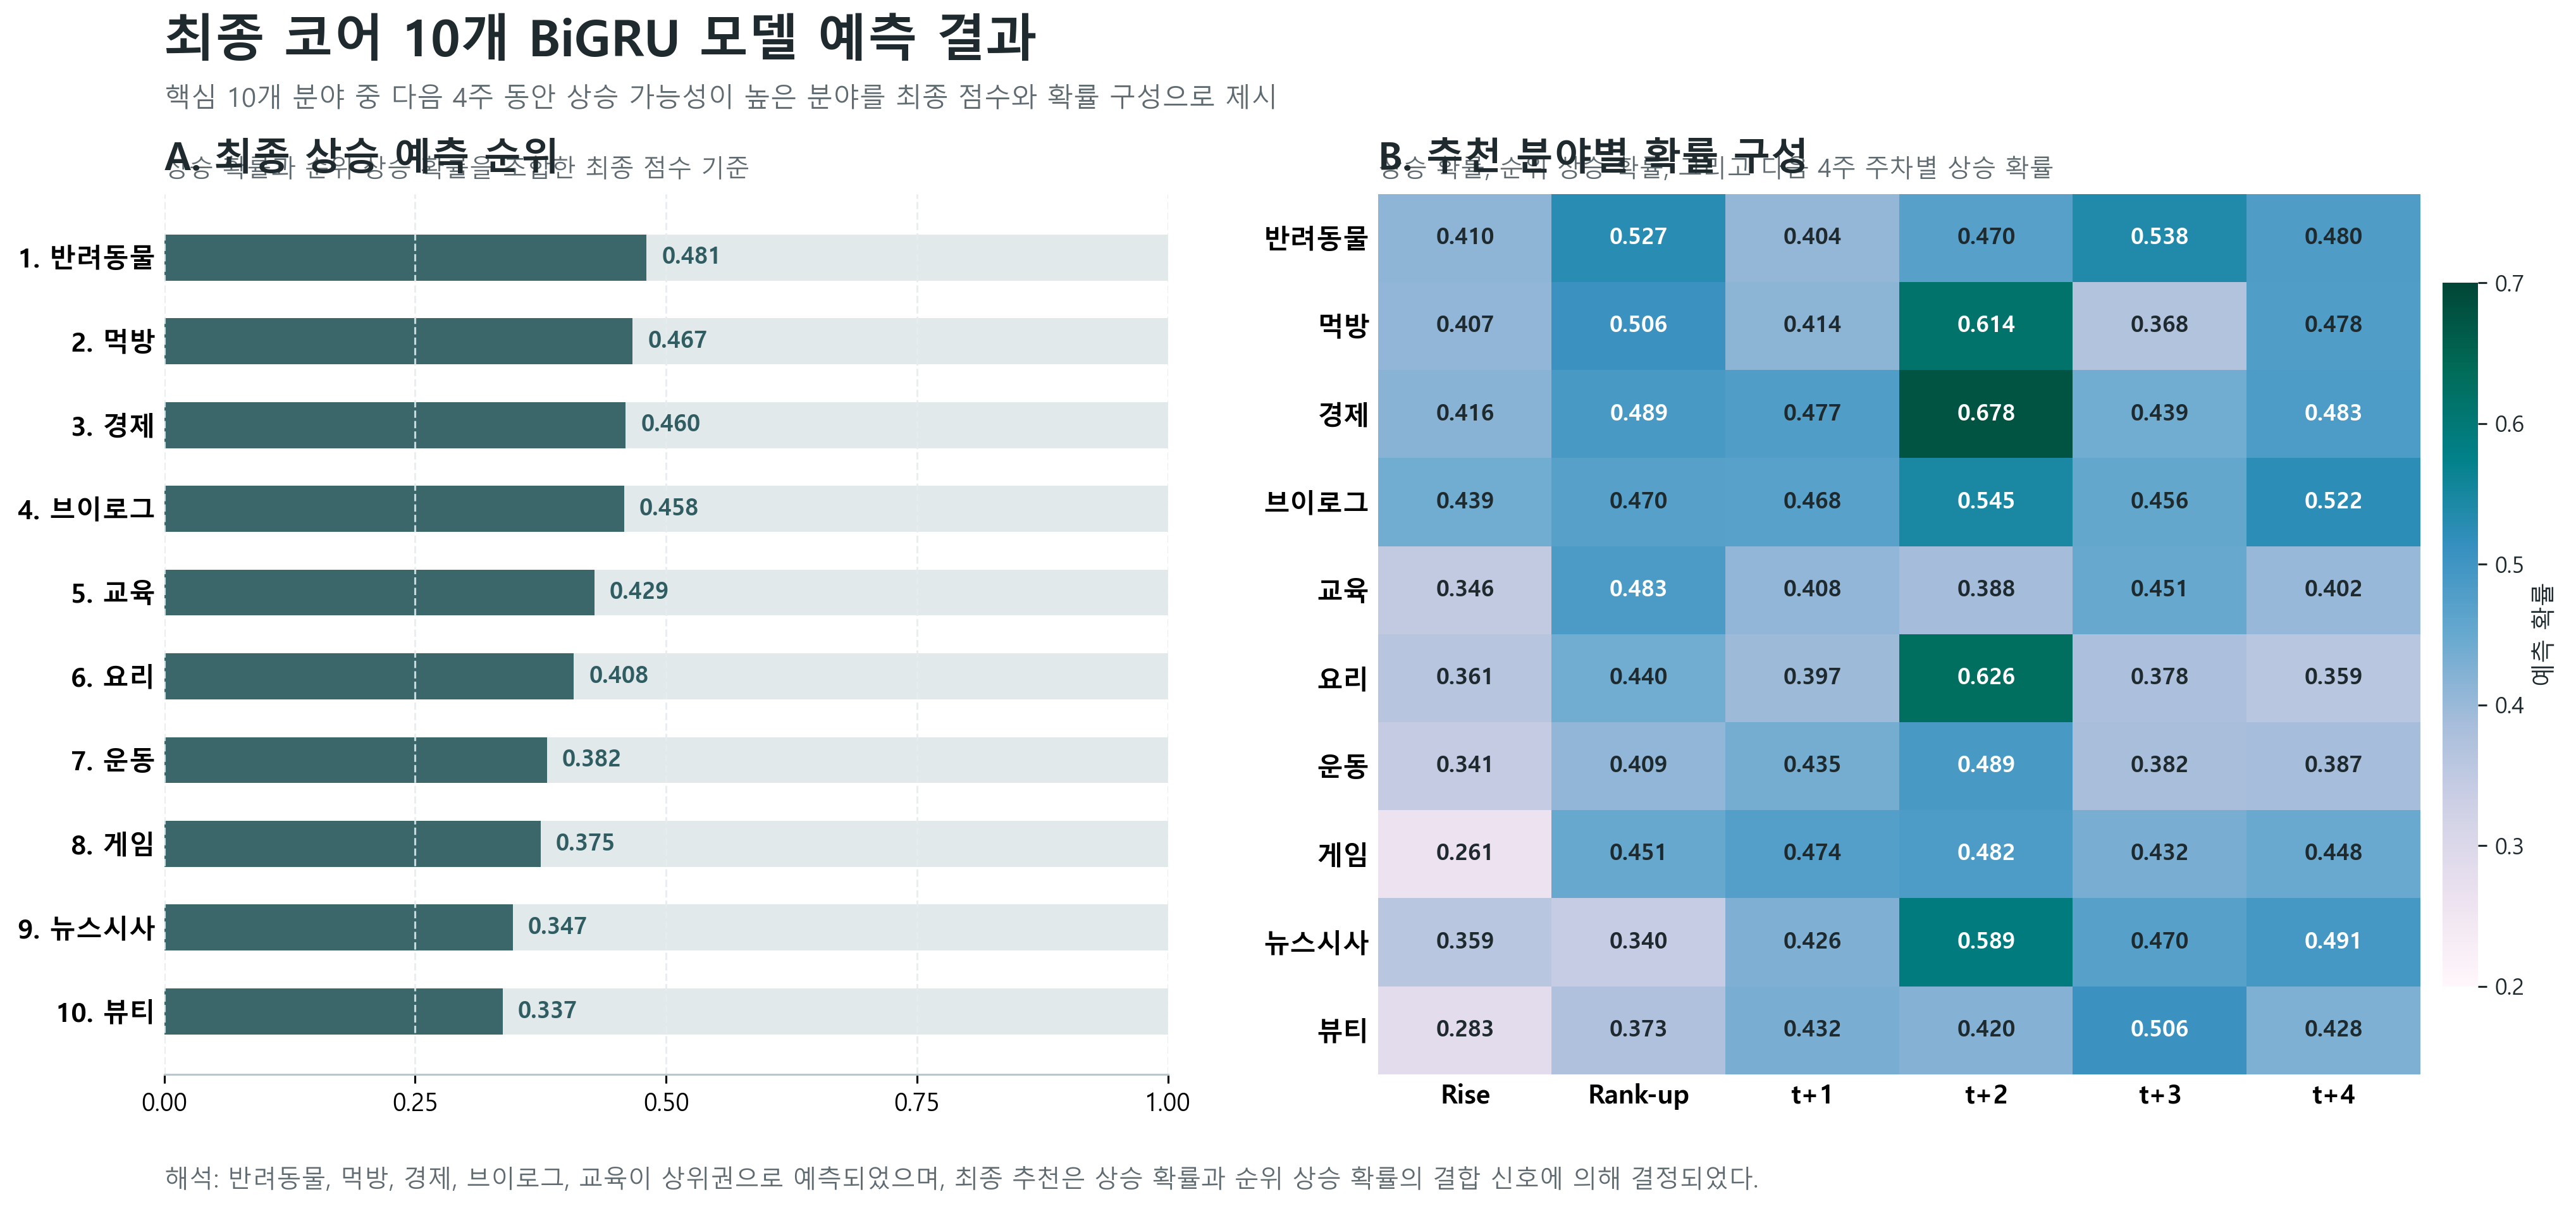

In [20]:
# 예측 결과 Figure 1: 최종 점수 순위 + 확률 구성
merged_pred = top_df.merge(future_df, on="category", how="left", suffixes=("", "_future"))
merged_pred = merged_pred.sort_values("final_score", ascending=False).reset_index(drop=True)
merged_pred["rank"] = np.arange(1, len(merged_pred) + 1)

left_df = merged_pred.copy().sort_values("final_score", ascending=True)
y = np.arange(len(left_df))

heat_cols = [
    "rise_probability",
    "rank_up_probability",
    "step1_up_probability",
    "step2_up_probability",
    "step3_up_probability",
    "step4_up_probability",
]
heat_labels = ["Rise", "Rank-up", "t+1", "t+2", "t+3", "t+4"]
heat_df = merged_pred.set_index("category")[heat_cols]

fig = plt.figure(figsize=(14.2, 7.1), dpi=280)
gs = fig.add_gridspec(1, 2, width_ratios=[1.05, 1.15], left=0.06, right=0.98, top=0.84, bottom=0.14, wspace=0.20)

ax1 = fig.add_subplot(gs[0, 0])
ax1.barh(y, left_df["final_score"], color=TEAL, height=0.55, alpha=0.94)
ax1.barh(y, 1 - left_df["final_score"], left=left_df["final_score"], color="#DCE6E8", height=0.55, alpha=0.85)
for yi, row in enumerate(left_df.itertuples(index=False)):
    ax1.text(row.final_score + 0.015, yi, f"{row.final_score:.3f}", va="center", ha="left", fontsize=9.4, color=TEAL, fontweight="bold")
ax1.set_yticks(y)
ax1.set_yticklabels([f"{r}. {c}" for r, c in zip(left_df["rank"], left_df["category"])], fontsize=10.8, fontweight="bold")
ax1.set_xlim(0.0, 1.0)
ax1.set_xticks([0.0, 0.25, 0.50, 0.75, 1.0])
clean_axis(ax1, grid_axis="x")
ax1.set_title("A. 최종 상승 예측 순위", loc="left", fontsize=15.5, fontweight="bold", color=TEXT, pad=10)
ax1.text(0.0, 1.02, "상승 확률과 순위 상승 확률을 조합한 최종 점수 기준", transform=ax1.transAxes, fontsize=10.0, color=SUBTEXT)

ax2 = fig.add_subplot(gs[0, 1])
mat = heat_df.to_numpy(dtype=float)
im = ax2.imshow(mat, cmap="PuBuGn", aspect="auto", vmin=0.20, vmax=0.70)
ax2.set_xticks(np.arange(len(heat_labels)))
ax2.set_xticklabels(heat_labels, fontsize=10.5, fontweight="bold")
ax2.set_yticks(np.arange(len(heat_df.index)))
ax2.set_yticklabels(heat_df.index.tolist(), fontsize=10.8, fontweight="bold")
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        value = mat[i, j]
        color = "white" if value >= 0.48 else TEXT
        ax2.text(j, i, f"{value:.3f}", ha="center", va="center", fontsize=9.2, color=color, fontweight="bold")
for side in ["top", "right", "left", "bottom"]:
    ax2.spines[side].set_visible(False)
ax2.tick_params(axis="both", length=0)
ax2.set_title("B. 추천 분야별 확률 구성", loc="left", fontsize=15.5, fontweight="bold", color=TEXT, pad=10)
ax2.text(0.0, 1.02, "상승 확률, 순위 상승 확률, 그리고 다음 4주 주차별 상승 확률", transform=ax2.transAxes, fontsize=10.0, color=SUBTEXT)
cbar = fig.colorbar(im, ax=ax2, fraction=0.032, pad=0.02)
cbar.outline.set_visible(False)
cbar.ax.tick_params(labelsize=9.2, colors=TEXT)
cbar.set_label("예측 확률", fontsize=9.8, color=TEXT)

fig.text(0.06, 0.95, "최종 코어 10개 BiGRU 모델 예측 결과", fontsize=20.5, fontweight="bold", color=TEXT, ha="left")
fig.text(0.06, 0.91, "핵심 10개 분야 중 다음 4주 동안 상승 가능성이 높은 분야를 최종 점수와 확률 구성으로 제시", fontsize=10.8, color=SUBTEXT, ha="left")
fig.text(0.06, 0.05, "해석: 반려동물, 먹방, 경제, 브이로그, 교육이 상위권으로 예측되었으며, 최종 추천은 상승 확률과 순위 상승 확률의 결합 신호에 의해 결정되었다.", fontsize=10.0, color=SUBTEXT, ha="left")
plt.show()

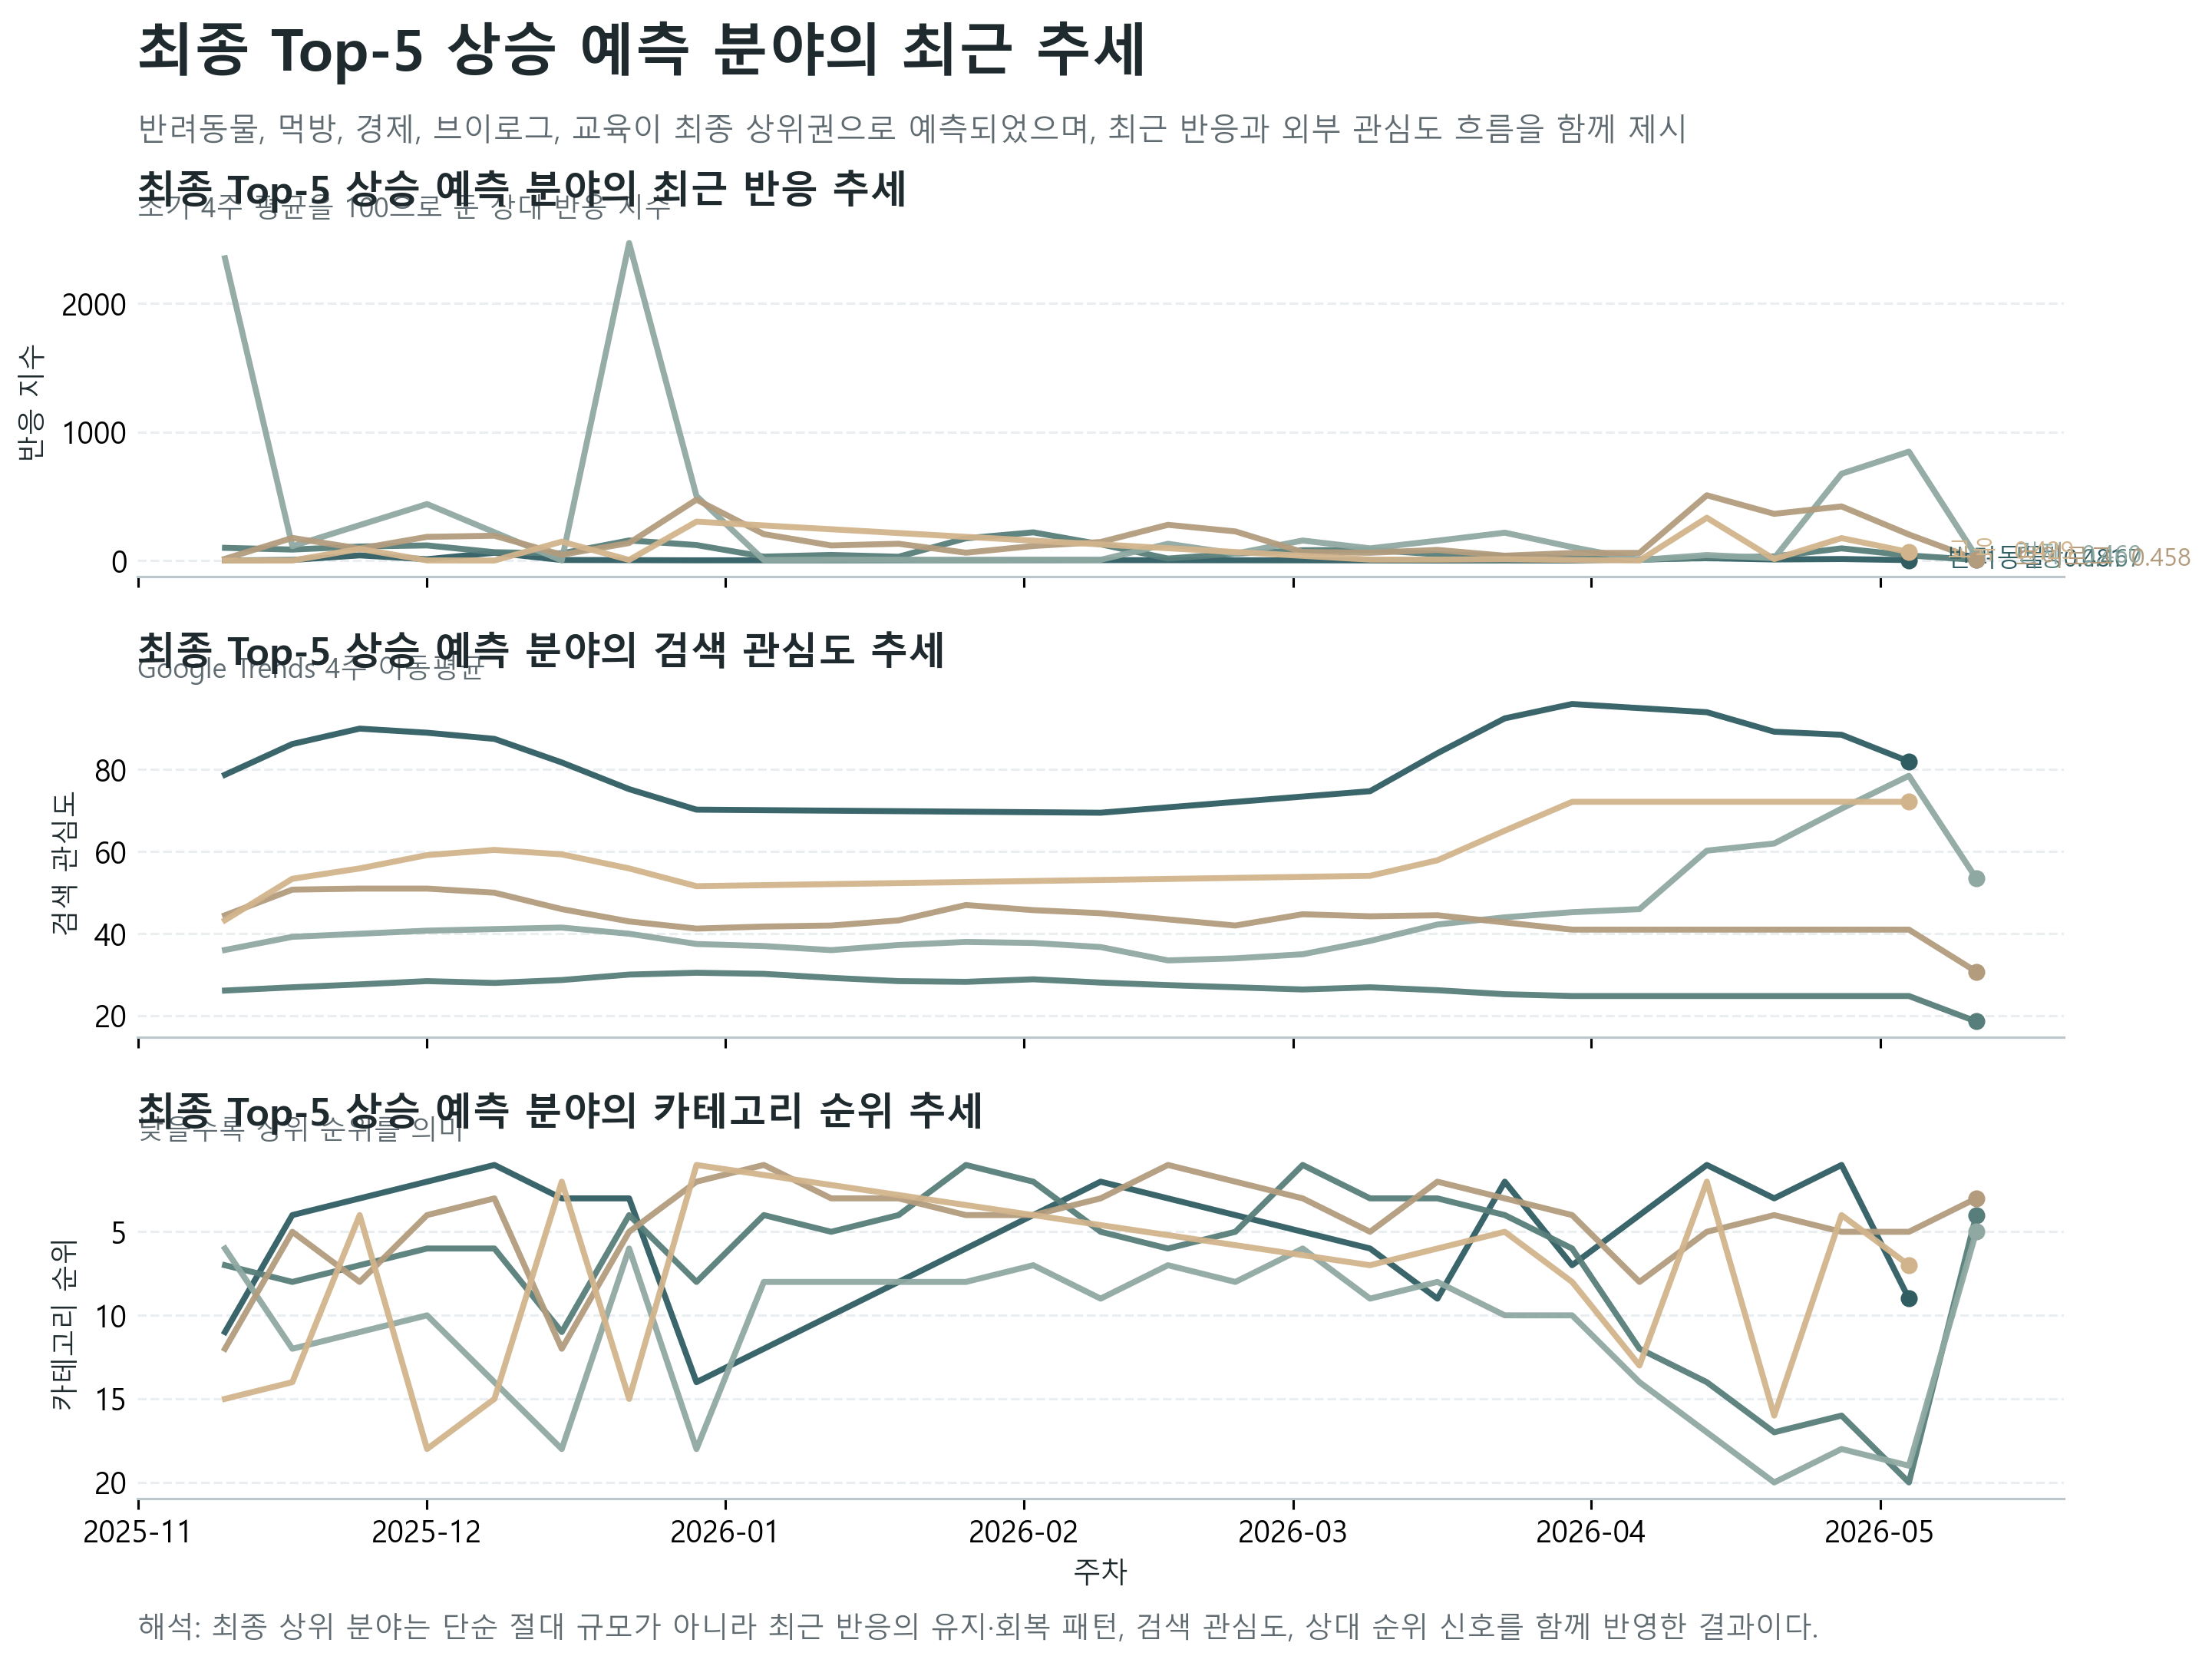

In [21]:
# 예측 결과 Figure 2: Top-5 분야 최근 추세 스토리
story_categories = top_df.sort_values("final_score", ascending=False).head(5)["category"].tolist()
story_df = feature_df[feature_df["category"].isin(story_categories)].copy()
story_df = story_df.loc[story_df["week_date"] >= story_df["week_date"].max() - pd.Timedelta(weeks=26)].copy()
score_map = dict(zip(top_df["category"], top_df["final_score"]))

palette = {
    story_categories[0]: "#2F5D62",
    story_categories[1]: "#577E7A",
    story_categories[2]: "#8FA8A2",
    story_categories[3]: "#B39C7D",
    story_categories[4]: "#D2B48C",
}

fig, axes = plt.subplots(3, 1, figsize=(10.8, 8.1), dpi=280, sharex=True)
plt.subplots_adjust(left=0.09, right=0.92, top=0.85, bottom=0.12, hspace=0.32)

ax = axes[0]
for category in story_categories:
    sub = story_df.loc[story_df["category"] == category].sort_values("week_date")
    ax.plot(sub["week_date"], sub["response_index"], color=palette[category], linewidth=2.0, alpha=0.95)
    ax.scatter(sub["week_date"].iloc[-1], sub["response_index"].iloc[-1], s=22, color=palette[category], zorder=3)
    ax.text(sub["week_date"].iloc[-1] + pd.Timedelta(days=4), sub["response_index"].iloc[-1], f"{category}  {score_map[category]:.3f}", fontsize=8.3, color=palette[category], va="center")
clean_axis(ax)
ax.set_title("최종 Top-5 상승 예측 분야의 최근 반응 추세", loc="left", fontsize=12.8, fontweight="bold", color=TEXT, pad=8)
ax.text(0.0, 1.03, "초기 4주 평균을 100으로 둔 상대 반응 지수", transform=ax.transAxes, fontsize=9.1, color=SUBTEXT)
ax.set_ylabel("반응 지수", fontsize=9.2, color=TEXT)

ax = axes[1]
for category in story_categories:
    sub = story_df.loc[story_df["category"] == category].sort_values("week_date")
    ax.plot(sub["week_date"], sub["search_roll4"], color=palette[category], linewidth=2.0, alpha=0.95)
    ax.scatter(sub["week_date"].iloc[-1], sub["search_roll4"].iloc[-1], s=22, color=palette[category], zorder=3)
clean_axis(ax)
ax.set_title("최종 Top-5 상승 예측 분야의 검색 관심도 추세", loc="left", fontsize=12.8, fontweight="bold", color=TEXT, pad=8)
ax.text(0.0, 1.03, "Google Trends 4주 이동평균", transform=ax.transAxes, fontsize=9.1, color=SUBTEXT)
ax.set_ylabel("검색 관심도", fontsize=9.2, color=TEXT)

ax = axes[2]
for category in story_categories:
    sub = story_df.loc[story_df["category"] == category].sort_values("week_date")
    ax.plot(sub["week_date"], sub["category_rank"], color=palette[category], linewidth=2.0, alpha=0.95)
    ax.scatter(sub["week_date"].iloc[-1], sub["category_rank"].iloc[-1], s=22, color=palette[category], zorder=3)
clean_axis(ax)
ax.set_title("최종 Top-5 상승 예측 분야의 카테고리 순위 추세", loc="left", fontsize=12.8, fontweight="bold", color=TEXT, pad=8)
ax.text(0.0, 1.03, "낮을수록 상위 순위를 의미", transform=ax.transAxes, fontsize=9.1, color=SUBTEXT)
ax.set_ylabel("카테고리 순위", fontsize=9.2, color=TEXT)
ax.set_xlabel("주차", fontsize=9.4, color=TEXT)
ax.invert_yaxis()

fig.text(0.09, 0.94, "최종 Top-5 상승 예측 분야의 최근 추세", fontsize=19.0, fontweight="bold", color=TEXT, ha="left")
fig.text(0.09, 0.90, "반려동물, 먹방, 경제, 브이로그, 교육이 최종 상위권으로 예측되었으며, 최근 반응과 외부 관심도 흐름을 함께 제시", fontsize=10.2, color=SUBTEXT, ha="left")
fig.text(0.09, 0.04, "해석: 최종 상위 분야는 단순 절대 규모가 아니라 최근 반응의 유지·회복 패턴, 검색 관심도, 상대 순위 신호를 함께 반영한 결과이다.", fontsize=9.6, color=SUBTEXT, ha="left")
plt.show()

**기본 해석**  

- 반려동물, 먹방, 경제, 브이로그, 교육이 최종 상위권으로 예측되었다.  
- 최종 점수는 상승 확률과 순위 상승 확률을 함께 반영하여 계산하였다.  
- 상위 예측 분야는 최근 반응 추세가 완전히 꺾이기보다 유지·회복되는 패턴을 보였고, 검색 관심도 및 상대 순위 흐름 역시 비교적 양호했다.

### ?? ?? ?? 1. ??? ?? ????

? ??? ? ??? **?? ??**, **?? ?? ??**, **?? ??**? ? ?? ??? ? ??,  
? ?? ??? ???? ?????? ??? ? ?? ?????.


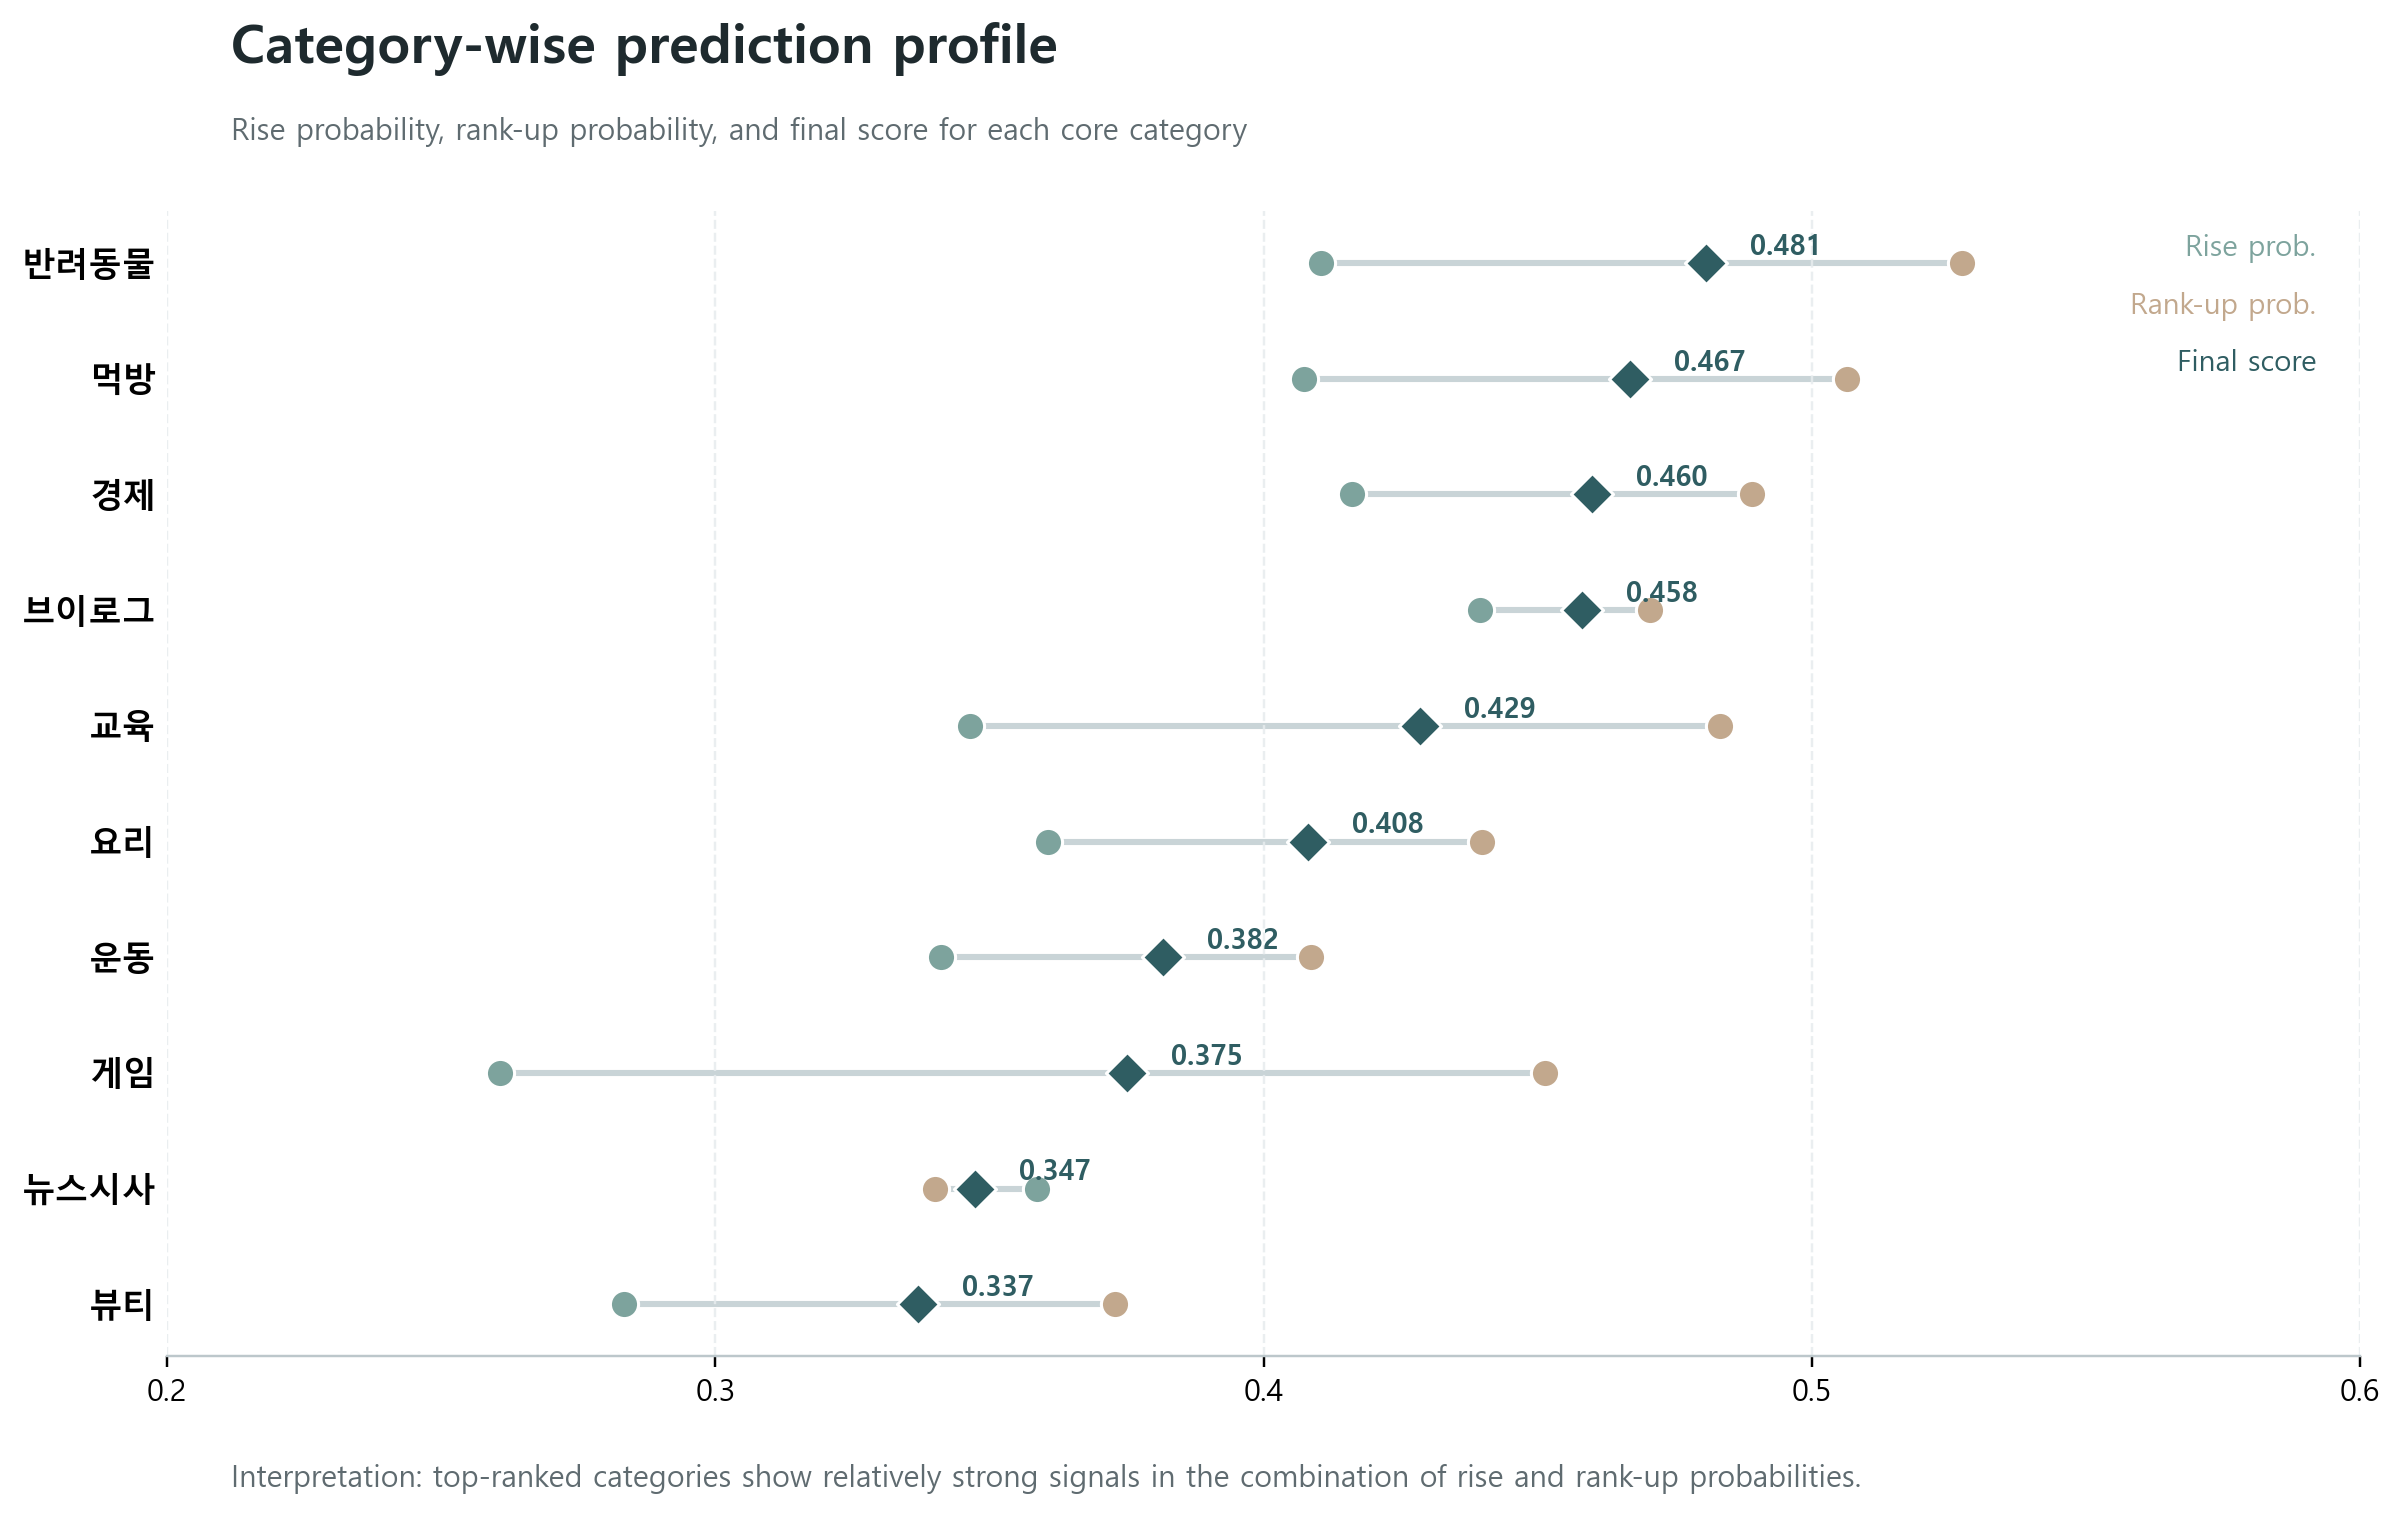

In [22]:
# Prediction Figure 3: category-wise probability profile
profile_df = top_df.sort_values("final_score", ascending=True).copy()
y = np.arange(len(profile_df))

fig, ax = plt.subplots(figsize=(11.6, 7.0), dpi=220)
for ii, row in enumerate(profile_df.itertuples(index=False)):
    low = min(row.rise_probability, row.rank_up_probability)
    high = max(row.rise_probability, row.rank_up_probability)
    ax.plot([low, high], [ii, ii], color=LINK, linewidth=2.0, zorder=1)
    ax.scatter(row.rise_probability, ii, s=85, color=TEAL_LIGHT, edgecolor="white", linewidth=1.0, zorder=3)
    ax.scatter(row.rank_up_probability, ii, s=85, color=SAND, edgecolor="white", linewidth=1.0, zorder=3)
    ax.scatter(row.final_score, ii, s=95, marker="D", color=TEAL, edgecolor="white", linewidth=1.0, zorder=4)
    ax.text(row.final_score + 0.008, ii + 0.14, f"{row.final_score:.3f}", fontsize=9.1, color=TEAL, ha="left", va="center", fontweight="bold")

ax.set_yticks(y)
ax.set_yticklabels(profile_df["category"], fontsize=11, fontweight="bold")
ax.set_xlim(0.20, 0.60)
ax.set_xticks([0.20, 0.30, 0.40, 0.50, 0.60])
clean_axis(ax, grid_axis="x")
ax.text(0.98, 0.98, "Rise prob.", transform=ax.transAxes, ha="right", va="top", fontsize=9.5, color=TEAL_LIGHT)
ax.text(0.98, 0.93, "Rank-up prob.", transform=ax.transAxes, ha="right", va="top", fontsize=9.5, color=SAND)
ax.text(0.98, 0.88, "Final score", transform=ax.transAxes, ha="right", va="top", fontsize=9.5, color=TEAL)
fig.text(0.125, 0.955, "Category-wise prediction profile", fontsize=17.5, fontweight="bold", color=TEXT, ha="left")
fig.text(0.125, 0.905, "Rise probability, rank-up probability, and final score for each core category", fontsize=9.8, color=SUBTEXT, ha="left")
fig.text(0.125, 0.03, "Interpretation: top-ranked categories show relatively strong signals in the combination of rise and rank-up probabilities.", fontsize=9.8, color=SUBTEXT)

plt.tight_layout(rect=[0.03, 0.06, 0.98, 0.88])
plt.savefig(FIG_DIR / "prediction_category_profile.png", dpi=300, bbox_inches="tight")
plt.show()


### ?? ?? ?? 2. 4? ?? ?? ?? Heatmap

? ??? ? ?? ??? t+1?? t+4?? ?? ?? ??? ???? ???? ???? ? ????.  
?? ??? ??? ? ??? ??????? ???? ?? ? ?????.


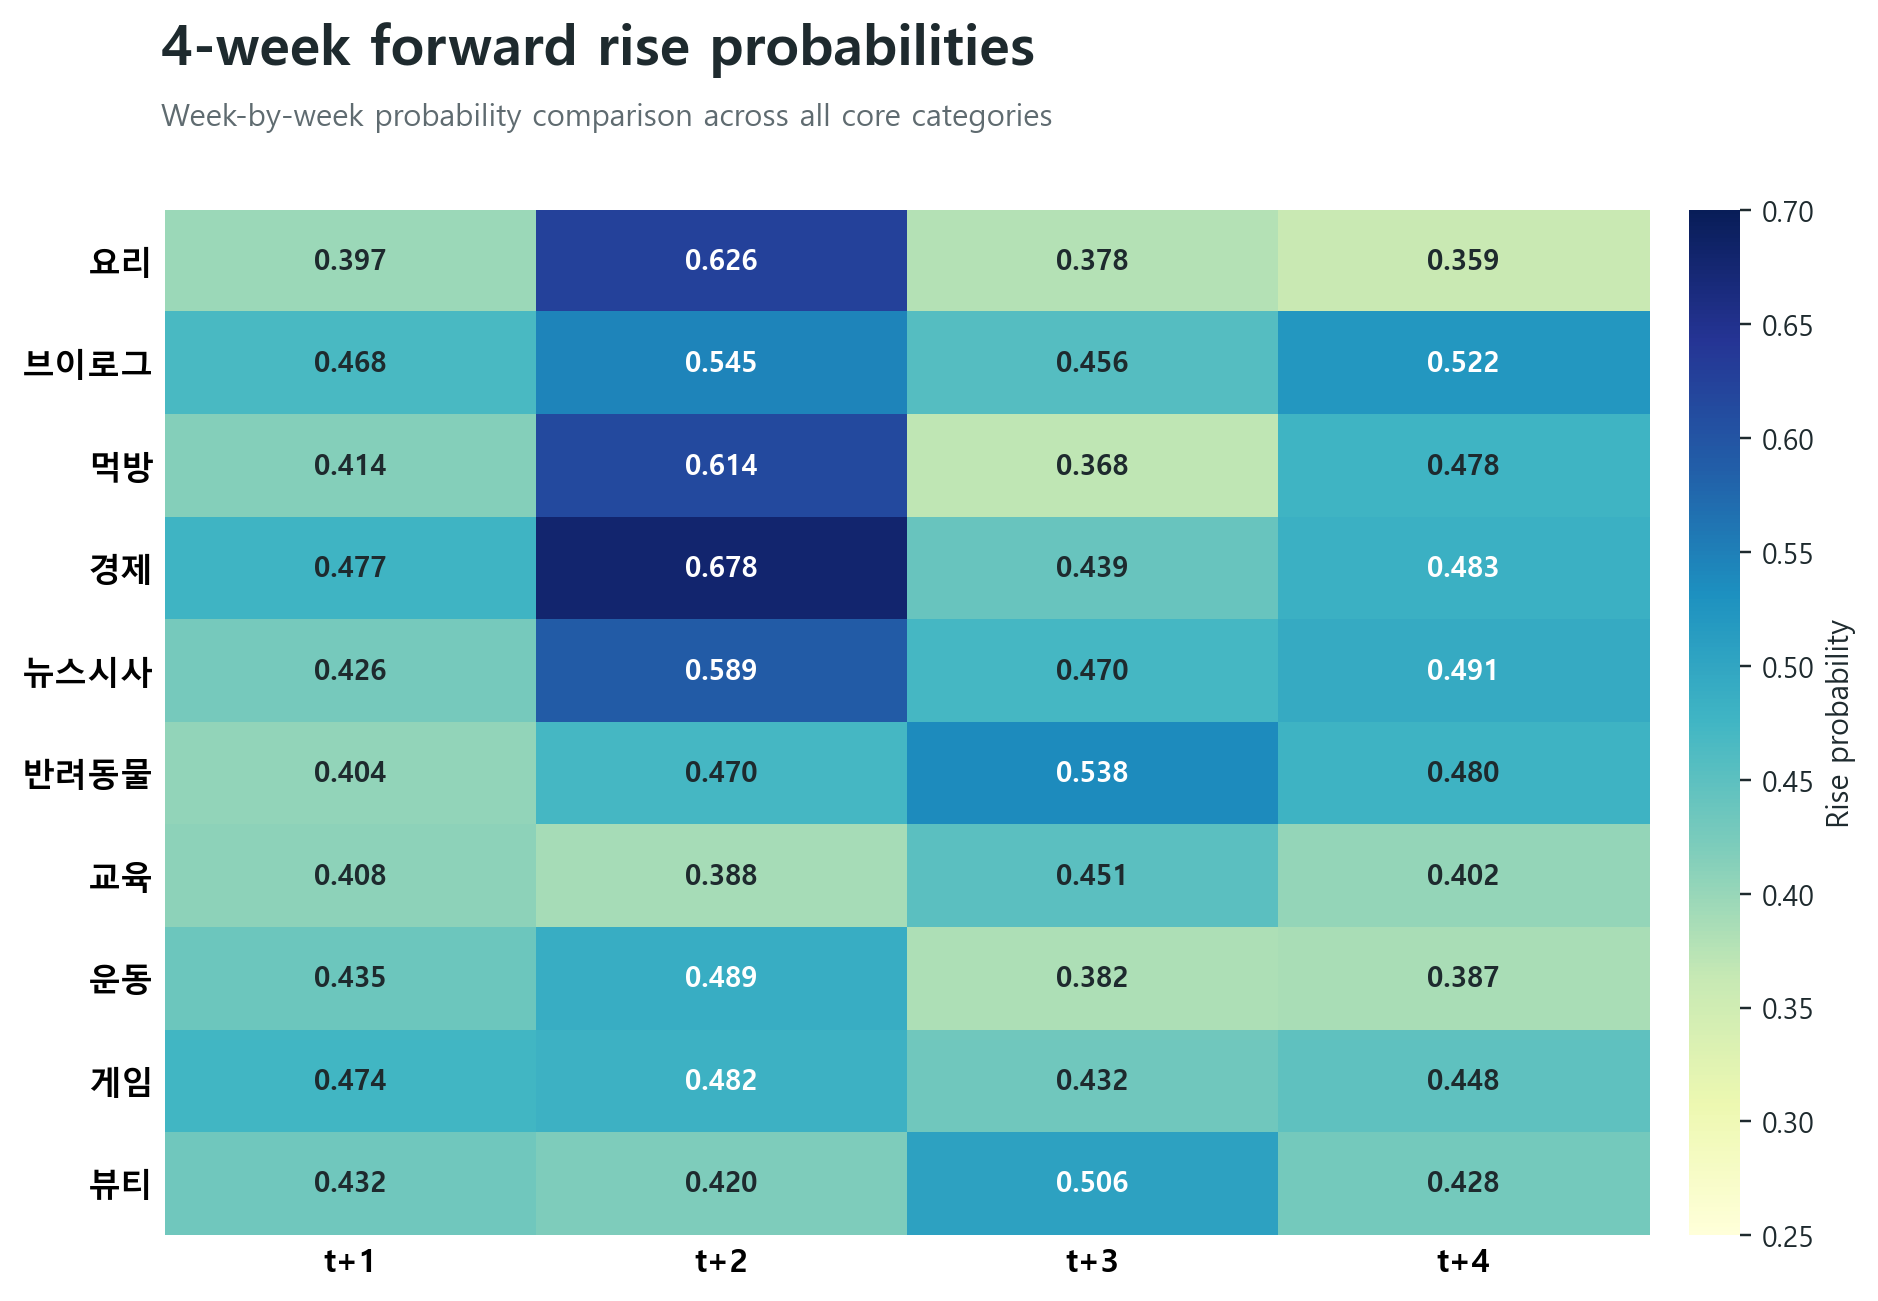

In [23]:
# Prediction Figure 4: 4-week forward probability heatmap
step_cols = ["step1_up_probability", "step2_up_probability", "step3_up_probability", "step4_up_probability"]
step_labels = ["t+1", "t+2", "t+3", "t+4"]
step_df = future_df.sort_values("ranking_score", ascending=False).set_index("category")[step_cols]

fig, ax = plt.subplots(figsize=(9.2, 6.2), dpi=220)
im = ax.imshow(step_df.values, cmap="YlGnBu", aspect="auto", vmin=0.25, vmax=0.70)
ax.set_xticks(np.arange(len(step_labels)))
ax.set_xticklabels(step_labels, fontsize=10.5, fontweight="bold")
ax.set_yticks(np.arange(len(step_df.index)))
ax.set_yticklabels(step_df.index.tolist(), fontsize=10.8, fontweight="bold")
for ii in range(step_df.shape[0]):
    for jj in range(step_df.shape[1]):
        value = step_df.iloc[ii, jj]
        color = "white" if value >= 0.48 else TEXT
        ax.text(jj, ii, f"{value:.3f}", ha="center", va="center", fontsize=9.2, color=color, fontweight="bold")
for side in ["top", "right", "left", "bottom"]:
    ax.spines[side].set_visible(False)
ax.tick_params(axis="both", length=0)
fig.text(0.125, 0.955, "4-week forward rise probabilities", fontsize=18.0, fontweight="bold", color=TEXT, ha="left")
fig.text(0.125, 0.91, "Week-by-week probability comparison across all core categories", fontsize=10.0, color=SUBTEXT, ha="left")
cbar = fig.colorbar(im, ax=ax, fraction=0.042, pad=0.025)
cbar.outline.set_visible(False)
cbar.ax.tick_params(labelsize=9.2, colors=TEXT)
cbar.set_label("Rise probability", fontsize=9.8, color=TEXT)

plt.tight_layout(rect=[0.04, 0.04, 0.98, 0.88])
plt.savefig(FIG_DIR / "prediction_step_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


### ?? ?? ?? 3. ??? 4? ?? ??

? ??? ? ?? ???? ?? 4? ?? ?? ??? ??? ????? **? ??? ??**? ????.  
?? heatmap?? ?? ? ???? ???? ?? ??? ??? ? ????.


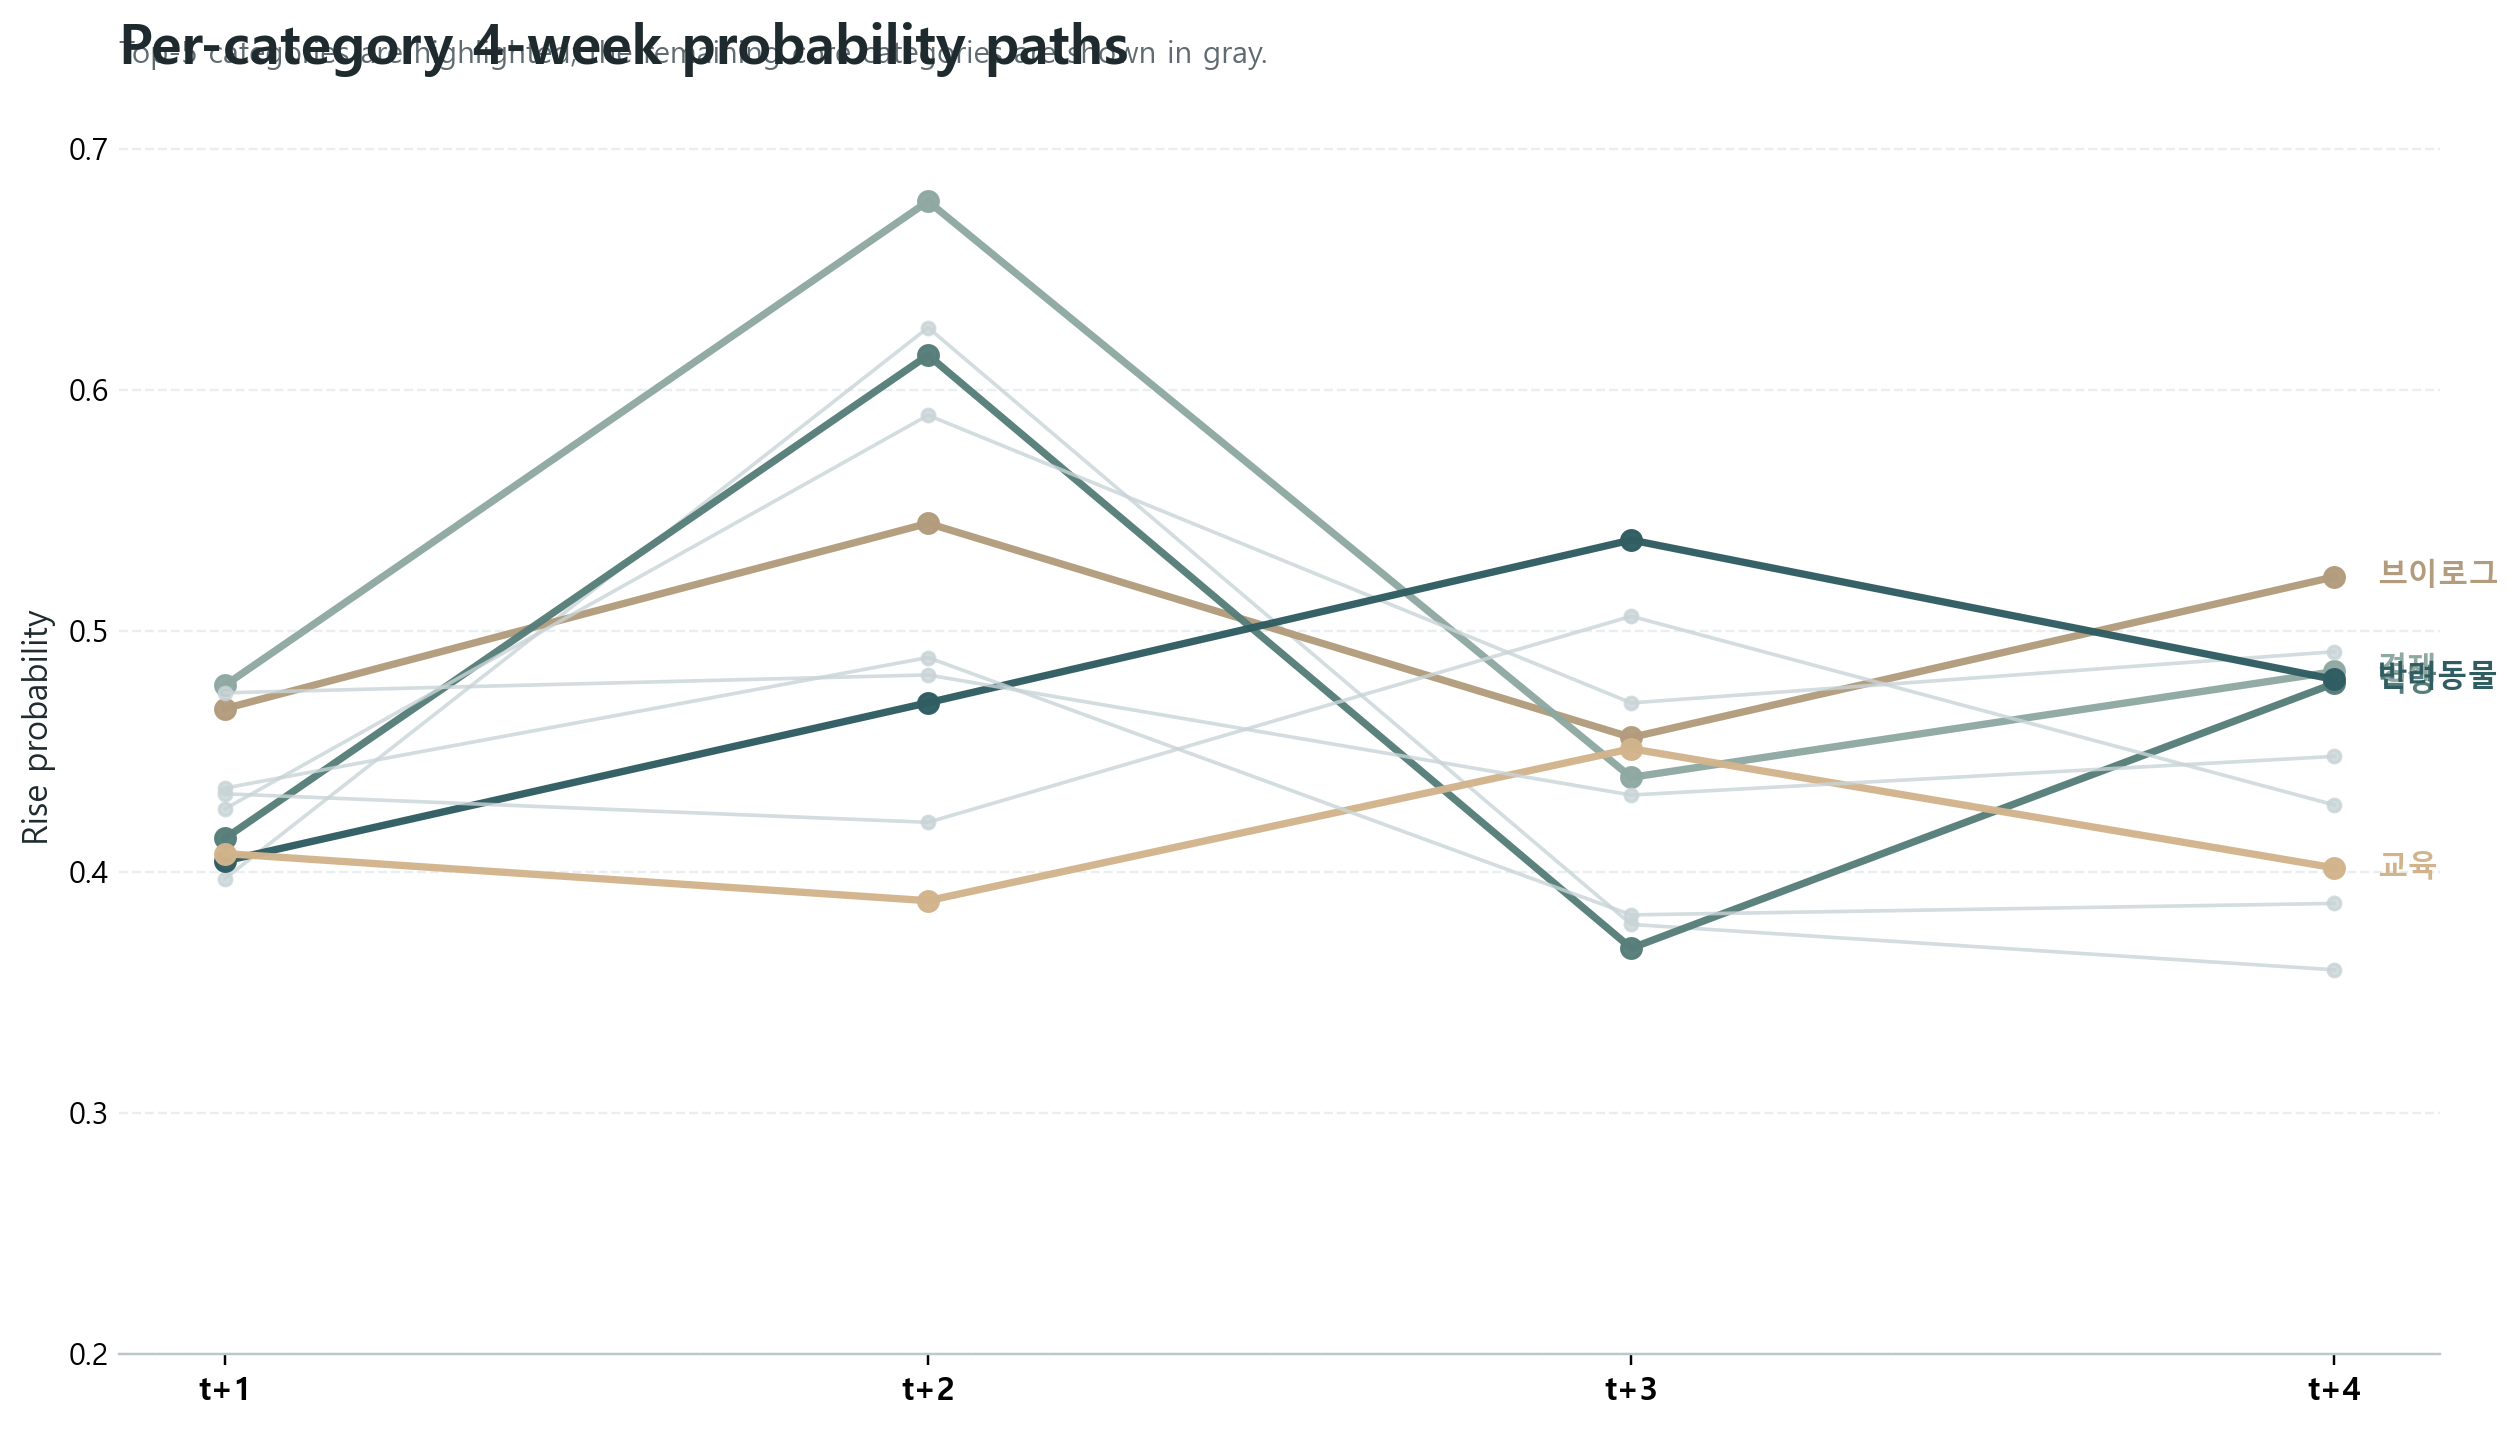

In [24]:
# Prediction Figure 5: per-category 4-week probability paths
traj_cols = ["step1_up_probability", "step2_up_probability", "step3_up_probability", "step4_up_probability"]
traj_labels = ["t+1", "t+2", "t+3", "t+4"]
traj_df = future_df[["category", "ranking_score"] + traj_cols].sort_values("ranking_score", ascending=False).copy()
highlight = set(top_df.sort_values("final_score", ascending=False).head(5)["category"].tolist())

traj_palette = {
    "반려동물": "#2F5D62",
    "먹방": "#577E7A",
    "경제": "#8FA8A2",
    "브이로그": "#B39C7D",
    "교육": "#D2B48C",
}

fig, ax = plt.subplots(figsize=(11.6, 6.6), dpi=220)
x = np.arange(1, 5)
for row in traj_df.itertuples(index=False):
    values = [getattr(row, c) for c in traj_cols]
    if row.category in highlight:
        color = traj_palette.get(row.category, TEAL)
        ax.plot(x, values, marker="o", linewidth=2.4, markersize=6.5, color=color, alpha=0.97)
        ax.text(x[-1] + 0.06, values[-1], row.category, color=color, fontsize=10.0, va="center", fontweight="bold")
    else:
        ax.plot(x, values, marker="o", linewidth=1.2, markersize=4.2, color="#C9D4D7", alpha=0.8)

clean_axis(ax, grid_axis="y")
ax.set_xticks(x)
ax.set_xticklabels(traj_labels, fontsize=10.5, fontweight="bold")
ax.set_ylim(0.20, 0.72)
ax.set_ylabel("Rise probability", fontsize=11.0, color=TEXT)
ax.set_title("Per-category 4-week probability paths", loc="left", fontsize=18, fontweight="bold", color=TEXT, pad=12)
ax.text(0.0, 1.03, "Top-5 categories are highlighted; the remaining core categories are shown in gray.", transform=ax.transAxes, fontsize=10.0, color=SUBTEXT)

plt.tight_layout()
plt.savefig(FIG_DIR / "prediction_probability_trajectories.png", dpi=300, bbox_inches="tight")
plt.show()


### ?? ?? ?? 4. ?? ??? Small Multiples ??

? ??? ? ?? ??? ?? ??? ??? t+1?? t+4??? ?? ??? ?? ????.  
?, EDA?? **??? ?? ??? ?? ???? ?? ?** ?? ? ?? ?? ????.


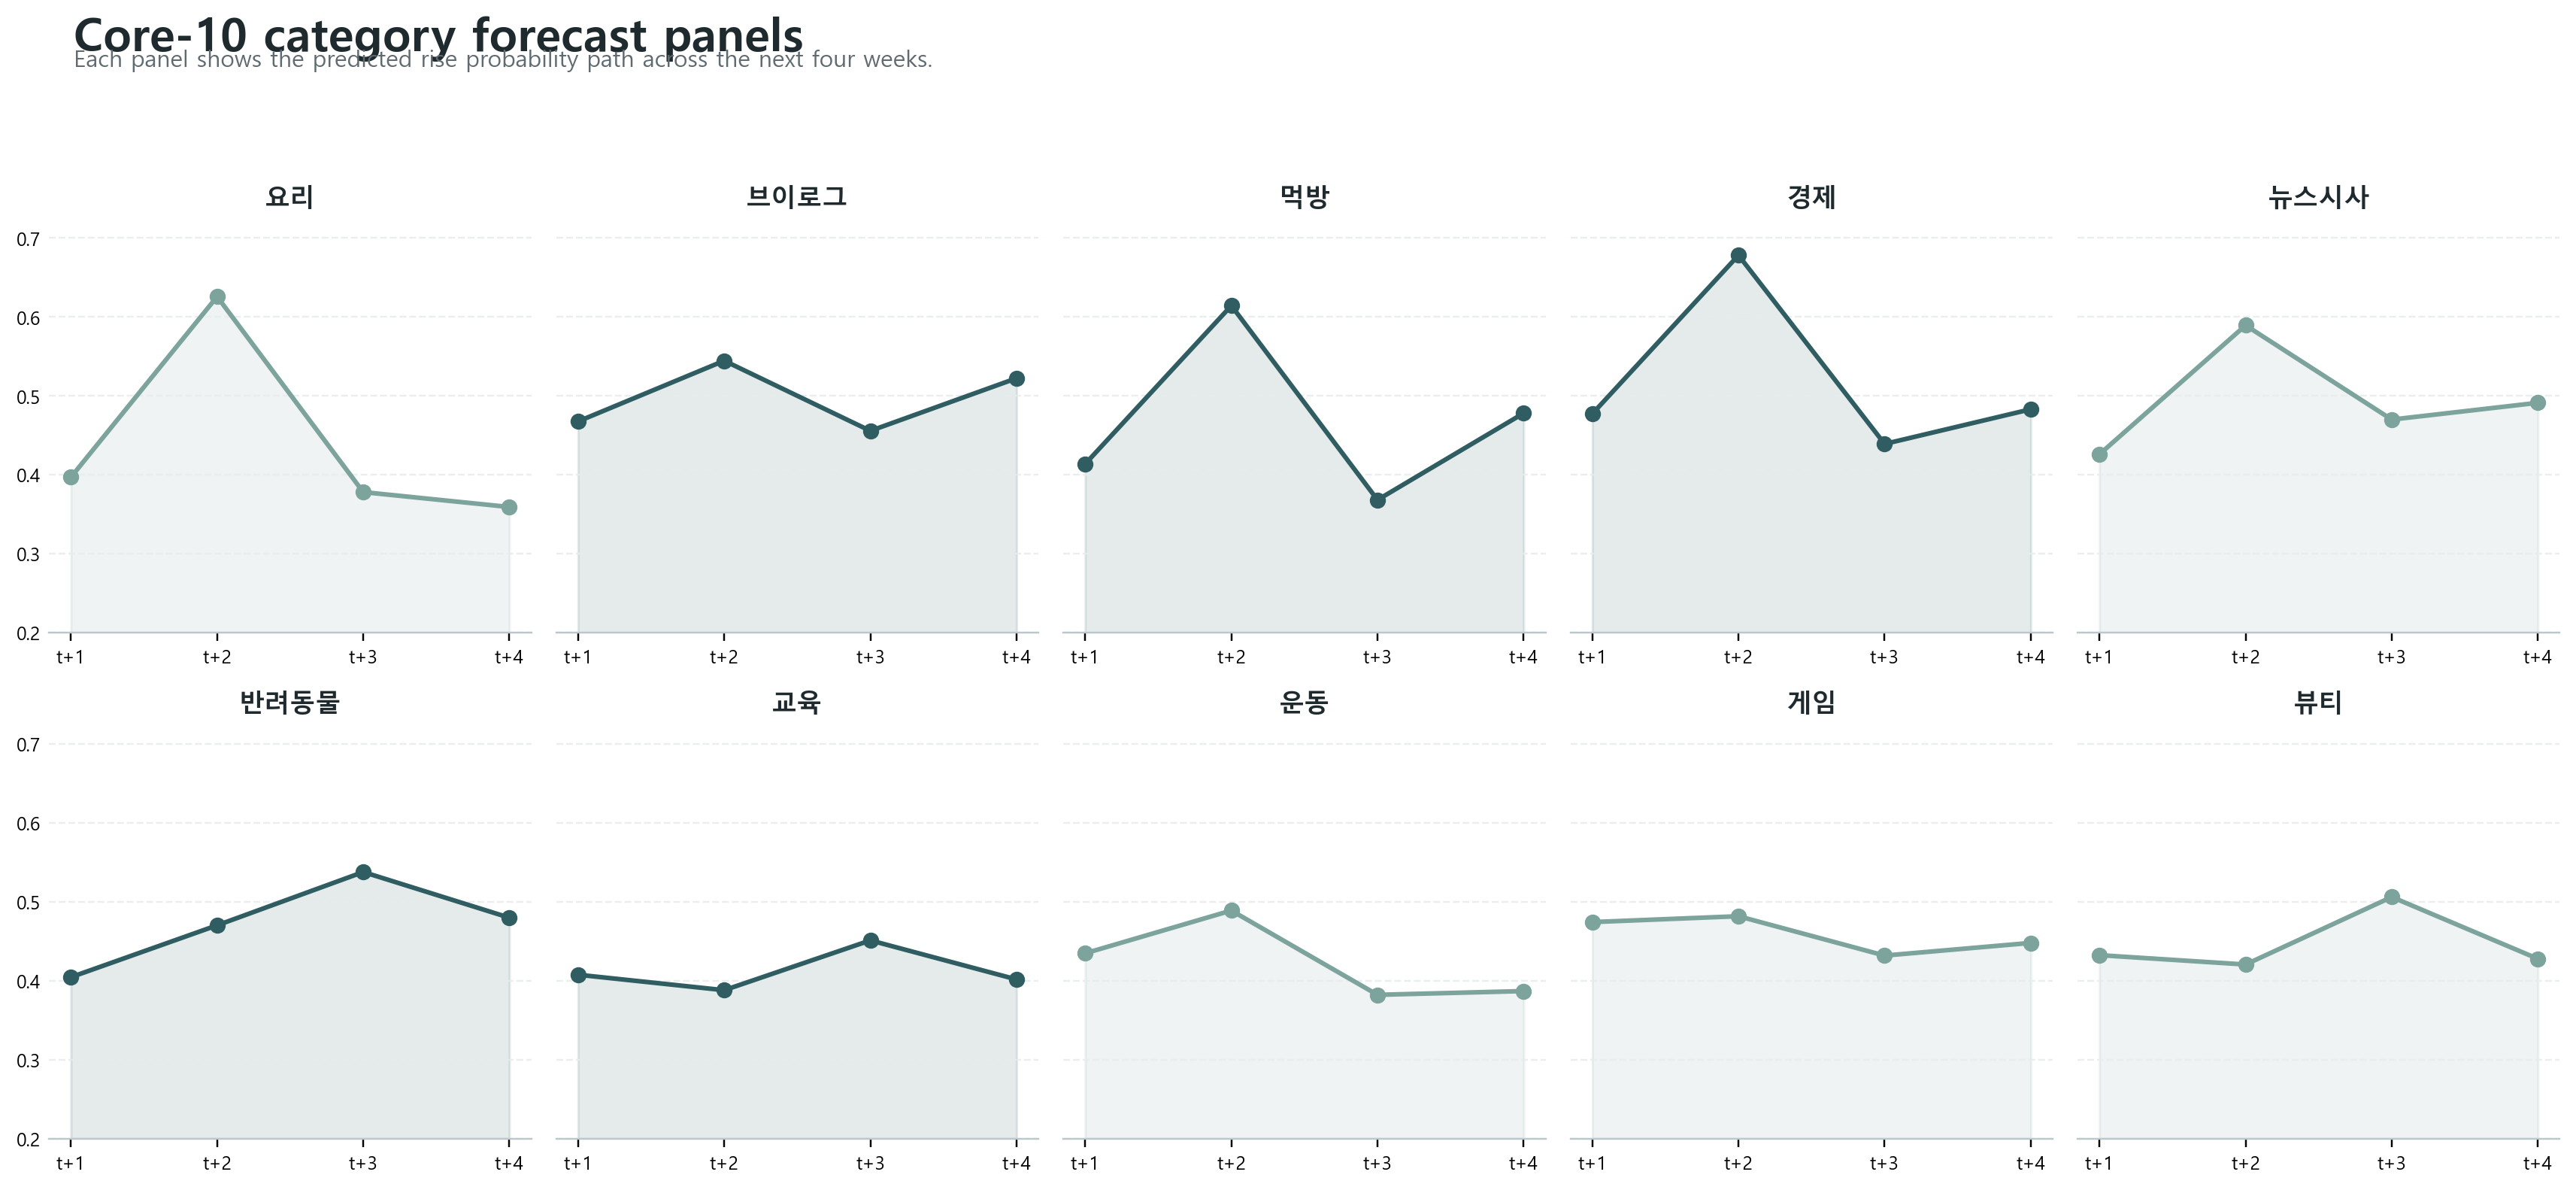

In [25]:
# Prediction Figure 6: small multiples for each category
panel_df = future_df[["category", "ranking_score", "step1_up_probability", "step2_up_probability", "step3_up_probability", "step4_up_probability"]].copy()
panel_df = panel_df.sort_values("ranking_score", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(2, 5, figsize=(16.5, 7.6), dpi=220, sharey=True)
axes = axes.flatten()
x = np.arange(1, 5)
labels = ["t+1", "t+2", "t+3", "t+4"]
top5 = set(top_df.sort_values("final_score", ascending=False).head(5)["category"].tolist())

for ax, row in zip(axes, panel_df.itertuples(index=False)):
    vals = [row.step1_up_probability, row.step2_up_probability, row.step3_up_probability, row.step4_up_probability]
    color = TEAL if row.category in top5 else TEAL_LIGHT
    ax.plot(x, vals, marker="o", linewidth=2.0, color=color)
    ax.fill_between(x, vals, 0.20, color=color, alpha=0.12)
    ax.set_title(row.category, fontsize=11.2, color=TEXT, pad=7, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylim(0.20, 0.72)
    clean_axis(ax, grid_axis="y")
    ax.tick_params(axis="y", labelsize=8)

fig.suptitle("Core-10 category forecast panels", x=0.06, y=0.98, ha="left", fontsize=20, fontweight="bold", color=TEXT)
fig.text(0.06, 0.94, "Each panel shows the predicted rise probability path across the next four weeks.", fontsize=10.2, color=SUBTEXT)
plt.tight_layout(rect=[0.03, 0.04, 0.98, 0.92])
plt.savefig(FIG_DIR / "prediction_small_multiples.png", dpi=300, bbox_inches="tight")
plt.show()


**?? ??**  

?? ??? ?? ?? ?? ??? ???, **?? ??**, **?? ?? ??**, **?? ?? ??**, **4? ?? ?? ??**? ?? ??? ??? ???? ??.  
??? ?? ??? ?? `?? ?? ???`, `??? ?? ????`, `4? ?? heatmap`, `??? 4? ??`, `small multiples ??` ? ??? ??? ???? ??.


### ?? ?? ??? ?? ???

- **?? ?? ???**: `?? ?? Figure 1`(?? ?? + ?? ??)
- **?? ?? ???**: `Prediction Figure 3`(??? ?? ????)
- **??? ?? ???**: `Prediction Figure 4`(4? ?? ?? heatmap)
- **??? ???? ???**: `Prediction Figure 5`, `Prediction Figure 6`
- **??/??????**: `?? ?? Figure 2`(Top-5 ?? ?? ???)


## 9. 결론 및 향후 과제

### ??

? ??? ?? ???? ??, ?? 12? ??? ??, Google Trends ???, ??? ??? ??? **??? ?? 10? ??? ?? 4? ?? ???**? ???? ??? ??? ?????.  
?????? ?? ??? ??? ??? **BiGRU**? ????, ?? ??? ?? ?? ??? ?? ???? ??? ?????.  
? ?? ?? ??? `Accuracy 0.767`, `Balanced Accuracy 0.798`, `F1-score 0.829`, `ROC AUC 0.845`? ????, Top-5 ?? ??? `Precision@5 0.900`, `NDCG@5 0.881`? ????.  
?, ??? ??? ?? ???? ?? ????? ?????? **?? ??, ?? ??, ?? ???, ??? ??? ?? ???? ? ? ???**? ?? ????.

### ?? ??

- ? ? ??? ??? ???? ??? ??? ??? ???? ?? ??? ??.
- ??, ??, ?? ? ??? ??? ? ???? ???? ?? ???? ?? ??? ?? ??? ? ??.
- ?? ??, ??? ???, ??? ? ?? ??? ???? ?? ??? ? ?? ? ??.
- ???? ?? ?? ??? ??, ?? ??? ?? ??? ???? ??? ? ??.


## ??? ??

? ???? ?? ??????? ??? ?? ???? ???? ?????.  
???? ?? ????? ?? ??? ???? ?? ??? ? ??.

- `run_core10_top_predictions.py`
- `plot_core10_prediction_results.py`
- `plot_core10_prediction_story.py`

?? Jupyter ????? `__file__`? ???? ?? ??? ????, ?? ??? `Path.cwd()` ???? ?????.
